<a href="https://colab.research.google.com/github/gustavofurini/mestrado/blob/main/mestrado_datascience.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Aula 1 - Pandas e Estatísticas**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('https://jpbarddal.github.io/assets/data/datascience/Salaries.csv')
df.head(5)

,Unnamed: 0,rank,discipline,yrs.since.phd,yrs.service,sex,salary
0,1,Prof,B,19,18,Male,139750
1,2,Prof,B,20,16,Male,173200
2,3,AsstProf,B,4,3,Male,79750
3,4,Prof,B,45,39,Male,115000
4,5,Prof,B,40,41,Male,141500


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397 entries, 0 to 396
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Unnamed: 0     397 non-null    int64 
 1   rank           397 non-null    object
 2   discipline     397 non-null    object
 3   yrs.since.phd  397 non-null    int64 
 4   yrs.service    397 non-null    int64 
 5   sex            397 non-null    object
 6   salary         397 non-null    int64 
dtypes: int64(4), object(3)
memory usage: 21.8+ KB


In [ ]:
df.shape

(397, 7)

In [ ]:
df.columns

Index(['Unnamed: 0', 'rank', 'discipline', 'yrs.since.phd', 'yrs.service',
       'sex', 'salary'],
      dtype='object')

In [ ]:
df.isna()

,Unnamed: 0,rank,discipline,yrs.since.phd,yrs.service,sex,salary
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
392,False,False,False,False,False,False,False
393,False,False,False,False,False,False,False
394,False,False,False,False,False,False,False
395,False,False,False,False,False,False,False


In [ ]:
df.isna().sum()

,0
Unnamed: 0,0
rank,0
discipline,0
yrs.since.phd,0
yrs.service,0
sex,0
salary,0


In [ ]:
df = df.drop('Unnamed: 0', axis=1)

In [ ]:
# Salário médio
df['salary'].mean()

np.float64(113706.45843828715)

In [ ]:
# Maior salário
df['salary'].max()

231545

In [ ]:
# Menor salário
df['salary'].min()

57800

In [ ]:
# Desvio padrão
df['salary'].std()

30289.038694747804

In [ ]:
# Moda
df['salary'].mode()

,salary
0,92000


In [ ]:
# Mediana
df['salary'].median()

107300.0

In [ ]:
# Quartis
df['salary'].quantile([0.25, 0.5, 0.75])

,salary
0.25,91000.0
0.50,107300.0
0.75,134185.0


In [ ]:
# Os 10% dos professores que melhor ganham, ganham a partir de quanto?
df['salary'].quantile(0.9)

np.float64(152946.00000000003)

In [ ]:
df[['salary','yrs.service']].mean()
# Colchetes mais interno é a representação de uma lista

,0
salary,113706.458438
yrs.service,17.614610


In [ ]:
# Como identificar as linhas
moda = df['salary'].mode()
cond = df['salary'] == 92000
df[cond]

,rank,discipline,yrs.since.phd,yrs.service,sex,salary
146,AsstProf,B,4,4,Male,92000
151,AsstProf,B,4,4,Male,92000
154,AsstProf,B,4,0,Male,92000
179,AsstProf,B,3,3,Female,92000
197,AsstProf,B,4,4,Male,92000


In [ ]:
cond = df['salary'].isin(moda)
df[cond]

,rank,discipline,yrs.since.phd,yrs.service,sex,salary
146,AsstProf,B,4,4,Male,92000
151,AsstProf,B,4,4,Male,92000
154,AsstProf,B,4,0,Male,92000
179,AsstProf,B,3,3,Female,92000
197,AsstProf,B,4,4,Male,92000


In [ ]:
# Salário médio das professoras da disciplina A
cond_mulheres = df['sex'] == 'Female'
cond_disc_a = df['discipline'] == 'A'
df[cond_mulheres & cond_disc_a]['salary'].mean()

np.float64(89064.94444444444)

In [ ]:
# Salário médio das professoras da disciplina B
cond_mulheres = df['sex'] == 'Female'
cond_disc_b = df['discipline'] == 'B'
df[cond_mulheres & cond_disc_b]['salary'].mean()

np.float64(111234.52380952382)

In [ ]:
 # GROUPBY
df_mulheres = df[cond_mulheres]
df_mulheres.groupby('discipline')['salary'].mean()

,salary
discipline,
A,89064.944444
B,111234.523810


In [ ]:
df.groupby(['sex', 'discipline'])['salary'].mean()

sex     discipline
Female  A              89064.944444
        B             111234.523810
Male    A             110699.981595
        B             118760.374359
Name: salary, dtype: float64

In [ ]:
# Níveis de carreira de uma professor
df['rank'].unique()

array(['Prof', 'AsstProf', 'AssocProf'], dtype=object)

In [ ]:
# Média dos sálarios dos professor
df.groupby(['rank'])['salary'].mean()

,salary
rank,
AssocProf,93876.437500
AsstProf,80775.985075
Prof,126772.109023


In [ ]:
df.groupby(['rank'])['salary'].max()

,salary
rank,
AssocProf,126431
AsstProf,97032
Prof,231545


In [ ]:
# Menor, maior e salário médio dos professores por nível
df.groupby('rank')['salary'].agg(['min', 'max', 'mean'])

,min,max,mean
rank,,,
AssocProf,62884,126431,93876.437500
AsstProf,63100,97032,80775.985075
Prof,57800,231545,126772.109023


In [ ]:
# Quantidade de professores nas faixas de salário
salary = [0, 70000, 90000, 110000, float('inf')]
labels = ['<70k', '<90k', '<110k', '>=110k']

df['faixa_salarial'] = pd.cut(df['salary'], bins=salary, labels=labels, right=False)

contagem_por_faixa = df.groupby('faixa_salarial')['salary'].count()

contagem_por_faixa


<ipython-input-28-15295146434d>:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  contagem_por_faixa = df.groupby('faixa_salarial')['salary'].count()


,salary
faixa_salarial,
<70k,8
<90k,86
<110k,121
>=110k,182


In [ ]:
# Diferença entre os salários médios por gênero
df.groupby(['sex'])['salary'].agg(['mean'])

,mean
sex,
Female,101002.410256
Male,115090.418994


In [ ]:
# Diferença entre os salários médios por gênero e rank
df.groupby(['rank', 'sex'])['salary'].agg(['mean'])

mean
rank      sex                  
AssocProf Female   88512.800000
          Male     94869.703704
AsstProf  Female   78049.909091
          Male     81311.464286
Prof      Female  121967.611111
          Male    127120.822581

#**Aula 2 - Análises Univariadas**







#### **Visualizações**

<Axes: xlabel='salary', ylabel='Count'>

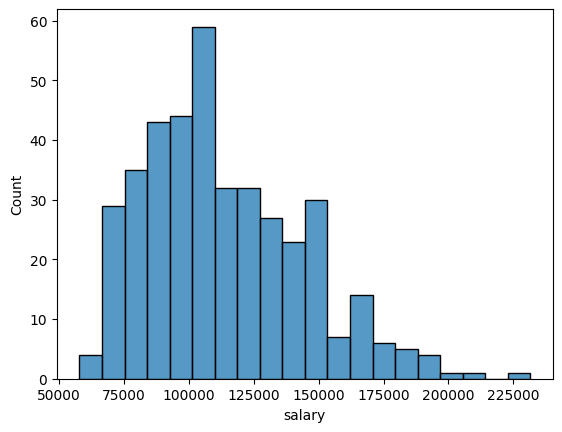

In [ ]:
# Histograma
sns.histplot(x=df['salary'], bins=20)
# Assimetria Adireita e Positiva

<Axes: xlabel='salary', ylabel='Density'>

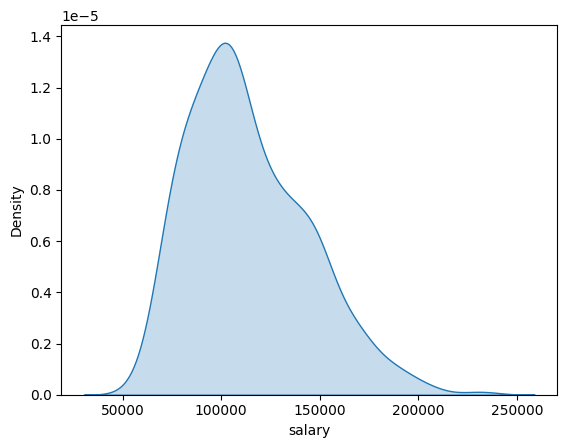

In [ ]:
# KDE Plot (densidade)
sns.kdeplot(x=df['salary'], fill=True)

<Axes: xlabel='salary'>

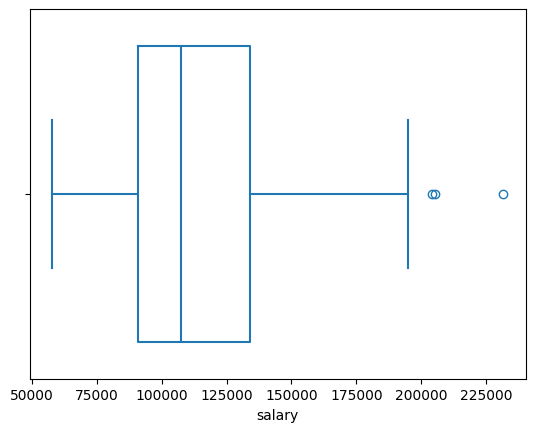

In [ ]:
# Box Plot
sns.boxplot(x=df['salary'], fill = False)
# Metade dos professores ganham entre 107 e 134 mil? Não
# Metade dos professores ganham mais do que 90 mil? Não

<Axes: xlabel='salary'>

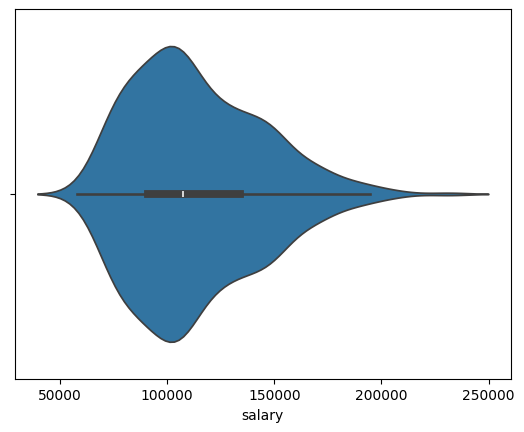

In [ ]:
# Violinplot
sns.violinplot(x=df['salary'])

<Axes: xlabel='rank', ylabel='count'>

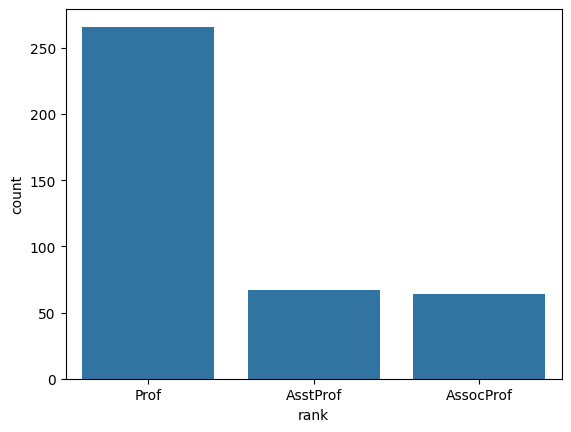

In [ ]:
# Gráfico de Barras
sns.countplot(x=df['rank'])

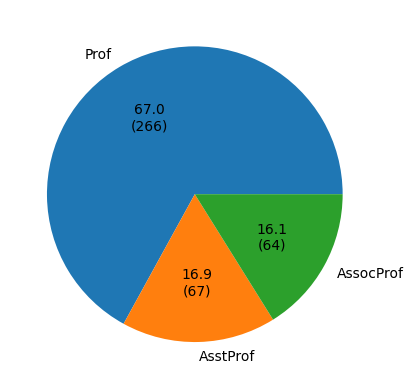

In [ ]:
# Gráfico de Pizza
def autopct_format(values):
  def myfmt(pct):
    total = sum(values)
    val = int(round(pct * total/100.0))
    return f'{pct:.1f}\n({val})'
  return myfmt

s = df['rank'].value_counts()
plt.pie(s, labels=s.index, autopct=autopct_format(s))
plt.show()

#### **Atividade**

In [ ]:
df2 = pd.read_csv('https://jpbarddal.github.io/assets/data/datascience/ommlbd_familiar.csv')
df2.replace(-9999, np.nan, inplace=True)

In [ ]:
df2.head(5)

,HS_CPF,QTDPESSOASCASA,MENORRENDACASA,MAIORRENDACASA,SOMARENDACASA,MEDIARENDACASA,MAIORIDADECASA,MENORIDADECASA,MEDIAIDADECASA,INDICMENORDEIDADE,COBRANCABAIXOCASA,COBRANCAMEDIOCASA,COBRANCAALTACASA,SEGMENTACAOFINBAIXACASA,SEGMENTACAOFINMEDIACASA,SEGMENTACAOALTACASA,BOLSAFAMILIACASA,FUNCIONARIOPUBLICOCASA
0,23325,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,667198,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,116666,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,129342,2.0,1000.0,1200.0,2200.0,1100.0,54.0,29.0,41.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,681531,5.0,400.0,1400.0,4400.0,880.0,43.0,16.0,25.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0


In [ ]:
100 * df2.isna().sum() / len(df2)

,0
HS_CPF,0.000000
QTDPESSOASCASA,62.289599
MENORRENDACASA,62.289599
MAIORRENDACASA,62.289599
SOMARENDACASA,62.289599
MEDIARENDACASA,62.289599
MAIORIDADECASA,62.300535
MENORIDADECASA,62.300535
MEDIAIDADECASA,62.300535
INDICMENORDEIDADE,62.289599


In [ ]:
df.shape

(397, 7)

In [ ]:
df2.columns

Index(['HS_CPF', 'QTDPESSOASCASA', 'MENORRENDACASA', 'MAIORRENDACASA',
       'SOMARENDACASA', 'MEDIARENDACASA', 'MAIORIDADECASA', 'MENORIDADECASA',
       'MEDIAIDADECASA', 'INDICMENORDEIDADE', 'COBRANCABAIXOCASA',
       'COBRANCAMEDIOCASA', 'COBRANCAALTACASA', 'SEGMENTACAOFINBAIXACASA',
       'SEGMENTACAOFINMEDIACASA', 'SEGMENTACAOALTACASA', 'BOLSAFAMILIACASA',
       'FUNCIONARIOPUBLICOCASA'],
      dtype='object')

In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438924 entries, 0 to 438923
Data columns (total 18 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   HS_CPF                   438924 non-null  int64  
 1   QTDPESSOASCASA           165520 non-null  float64
 2   MENORRENDACASA           165520 non-null  float64
 3   MAIORRENDACASA           165520 non-null  float64
 4   SOMARENDACASA            165520 non-null  float64
 5   MEDIARENDACASA           165520 non-null  float64
 6   MAIORIDADECASA           165472 non-null  float64
 7   MENORIDADECASA           165472 non-null  float64
 8   MEDIAIDADECASA           165472 non-null  float64
 9   INDICMENORDEIDADE        165520 non-null  float64
 10  COBRANCABAIXOCASA        165520 non-null  float64
 11  COBRANCAMEDIOCASA        165520 non-null  float64
 12  COBRANCAALTACASA         165520 non-null  float64
 13  SEGMENTACAOFINBAIXACASA  165520 non-null  float64
 14  SEGM

In [ ]:
df2.describe()

,HS_CPF,QTDPESSOASCASA,MENORRENDACASA,MAIORRENDACASA,SOMARENDACASA,MEDIARENDACASA,MAIORIDADECASA,MENORIDADECASA,MEDIAIDADECASA,INDICMENORDEIDADE,COBRANCABAIXOCASA,COBRANCAMEDIOCASA,COBRANCAALTACASA,SEGMENTACAOFINBAIXACASA,SEGMENTACAOFINMEDIACASA,SEGMENTACAOALTACASA,BOLSAFAMILIACASA,FUNCIONARIOPUBLICOCASA
count,438924.000000,165520.000000,165520.000000,165520.000000,165520.000000,165520.000000,165472.000000,165472.000000,165472.000000,165520.000000,165520.000000,165520.000000,165520.000000,165520.000000,165520.000000,165520.000000,165520.000000,165520.000000
mean,324130.294748,2.993542,1211.068753,5259.854398,8306.661431,2902.041409,50.904298,24.809690,36.196613,0.064669,0.059981,0.005486,0.003160,0.063575,0.001172,0.000085,0.206803,0.197499
std,205825.214515,1.231989,1438.357620,6079.701542,8445.786665,2984.834142,13.807128,10.886317,10.893769,0.245941,0.237452,0.073863,0.056123,0.243996,0.034215,0.009196,0.405014,0.398113
min,0.000000,2.000000,400.000000,400.000000,800.000000,400.000000,4.000000,1.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,147907.750000,2.000000,800.000000,1200.000000,2900.000000,1000.000000,42.000000,18.000000,29.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,294081.500000,3.000000,900.000000,3000.000000,5400.000000,1800.000000,49.000000,23.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,515903.250000,4.000000,1000.000000,7000.000000,10300.000000,3533.000000,58.000000,30.000000,42.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,698720.000000,10.000000,30000.000000,30000.000000,100000.000000,30000.000000,128.000000,103.000000,103.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


<Axes: xlabel='SOMARENDACASA', ylabel='Count'>

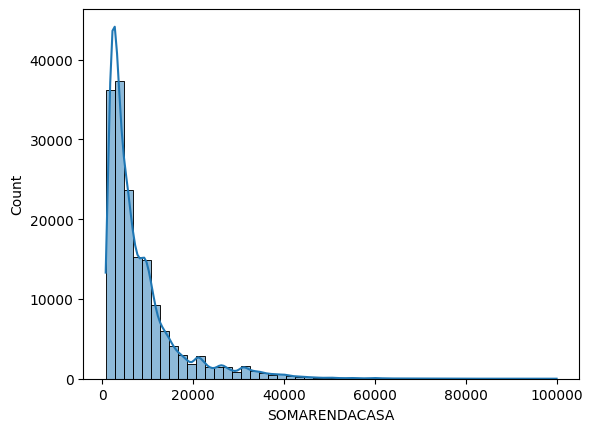

In [ ]:
sns.histplot(x=df2['SOMARENDACASA'], bins=50, kde=True)
# Assimétrica direita

<Axes: xlabel='SOMARENDACASA'>

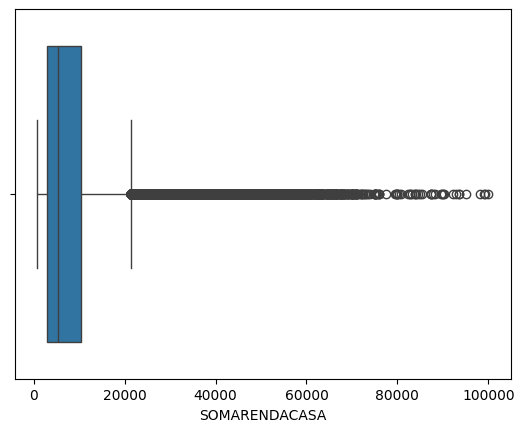

In [ ]:
sns.boxplot(x=df2['SOMARENDACASA'])

#### **Transformação de Dados**

In [ ]:
from sklearn.preprocessing import PowerTransformer

<Axes: xlabel='SOMARENDACASA', ylabel='Count'>

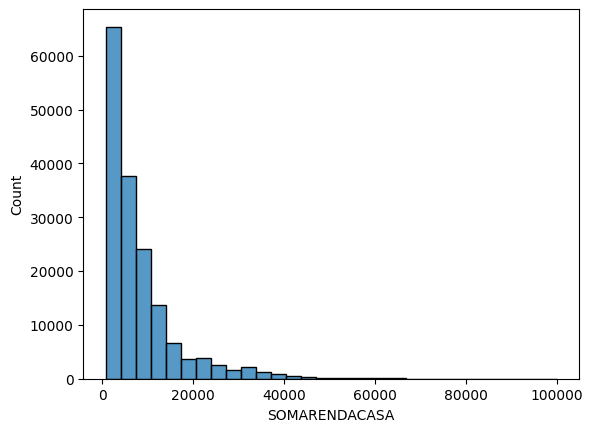

In [ ]:
rendas_antes = df2['SOMARENDACASA']
sns.histplot(x=rendas_antes, bins=30)

In [ ]:
# Box-cox: limitação (só funciona com dados positivos)
# Yeo-johnson: (aceita números, negativos, zero, positivos, etc)
#bc = PowerTransformer(method='box-cox')
bc = PowerTransformer(method='yeo-johnson')
rendas_depois = bc.fit_transform(rendas_antes.values.reshape(-1, 1))
# Melhor para modelagens preditivas

<Axes: ylabel='Count'>

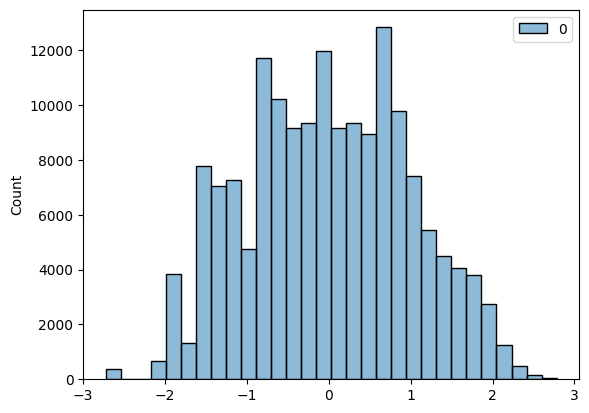

In [ ]:
sns.histplot(rendas_depois, bins=30)

<Axes: ylabel='Count'>

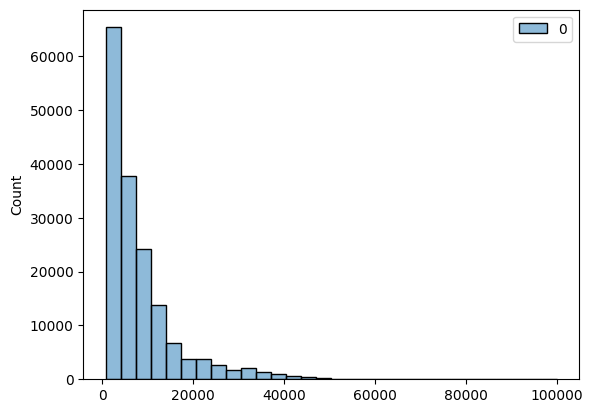

In [ ]:
renda_volta = bc.inverse_transform(rendas_depois)
sns.histplot(renda_volta, bins=30)

In [ ]:
transformador = PowerTransformer(method='yeo-johnson')
df_transformado = pd.DataFrame(data=transformador.fit_transform(df2), columns=df2.columns)

In [ ]:
# Invertigar: Pipeline (sklearn)

#**Aula 3 - Análises Multivariada de Dados**


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('https://jpbarddal.github.io/assets/data/datascience/Salaries.csv')
df.head(5)

,Unnamed: 0,rank,discipline,yrs.since.phd,yrs.service,sex,salary
0,1,Prof,B,19,18,Male,139750
1,2,Prof,B,20,16,Male,173200
2,3,AsstProf,B,4,3,Male,79750
3,4,Prof,B,45,39,Male,115000
4,5,Prof,B,40,41,Male,141500


<Axes: xlabel='yrs.service', ylabel='salary'>

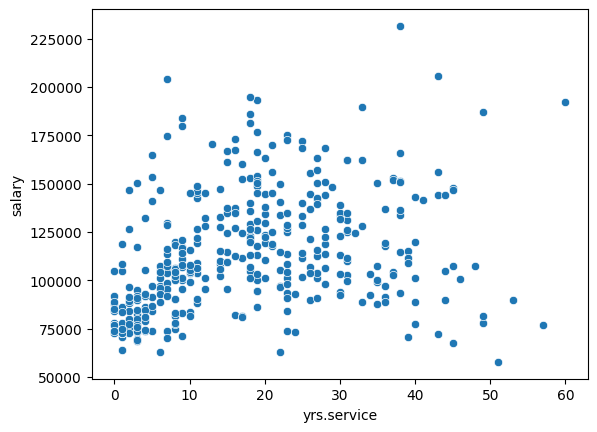

In [ ]:
# Scatterplot
sns.scatterplot(x=df['yrs.service'],
                y=df['salary'])

<Axes: xlabel='rank', ylabel='salary'>

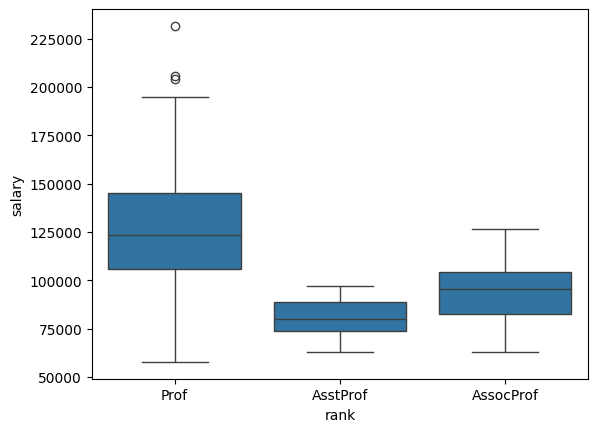

In [ ]:
# Passar do scatterplot para o boxplot, a consequencia ruim de não saber
# onde os dados estão exatamente mas temos uma visão melhor da proporção
sns.boxplot(x=df['rank'],
                y=df['salary'])

<Axes: xlabel='rank', ylabel='salary'>

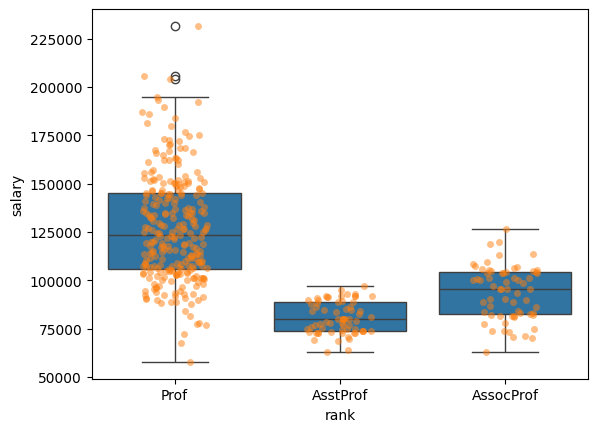

In [ ]:
sns.boxplot(x=df['rank'],
                y=df['salary'])
sns.stripplot(x=df['rank'],
                y=df['salary'], jitter=0.2, alpha=0.5)

<Axes: xlabel='rank', ylabel='salary'>

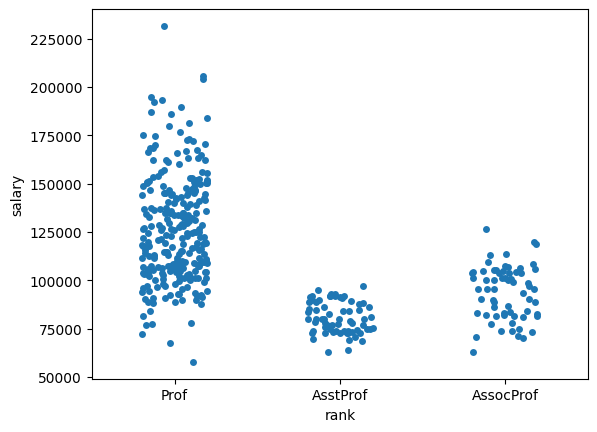

In [ ]:
sns.stripplot(x=df['rank'],
                y=df['salary'], jitter=0.2)

<Axes: xlabel='rank', ylabel='salary'>

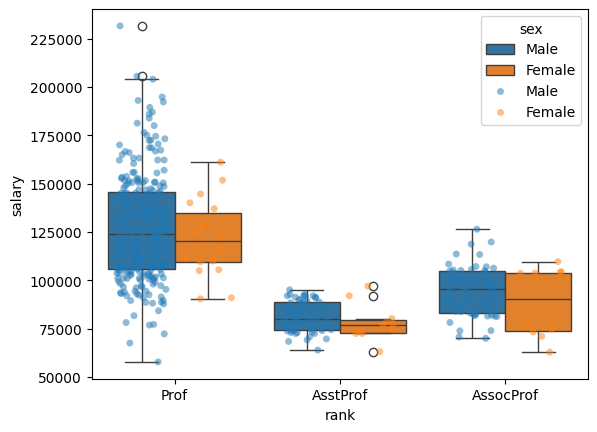

In [ ]:
sns.boxplot(x=df['rank'],
            y=df['salary'],
            hue=df['sex'])

sns.stripplot(x=df['rank'],
                y=df['salary'],
                hue=df['sex'],
                jitter=0.3,
                dodge=True,
                alpha=0.5)

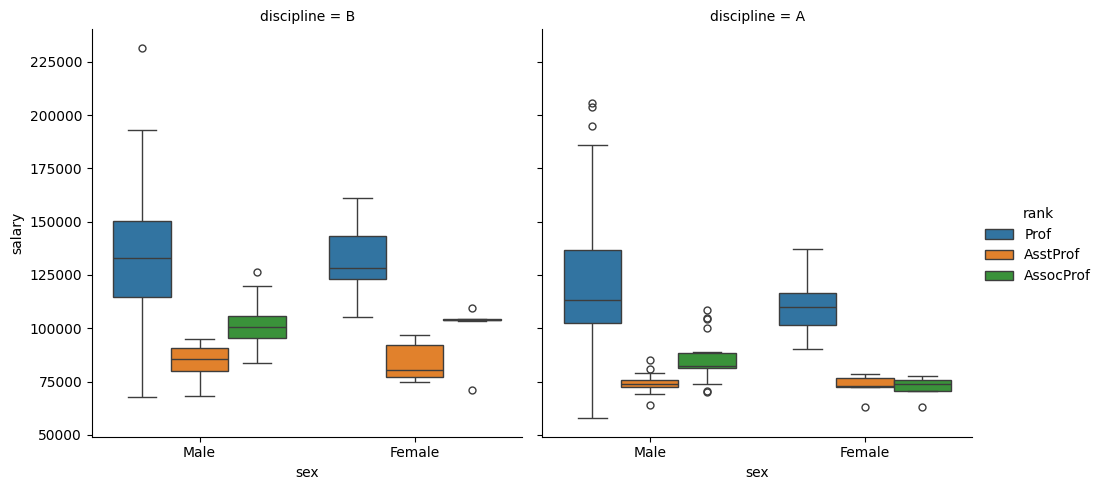

In [ ]:
sns.catplot(
    data=df,
    x="sex",
    y="salary",
    col="discipline",
    hue='rank',
    kind="box",
)

<Axes: xlabel='yrs.service', ylabel='salary'>

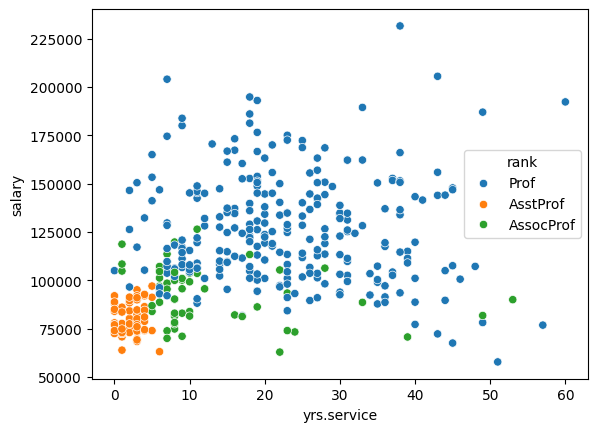

In [ ]:
# Cluster
sns.scatterplot(x=df['yrs.service'],
                y=df['salary'],
                hue=df['rank'])

<Axes: xlabel='yrs.service', ylabel='salary'>

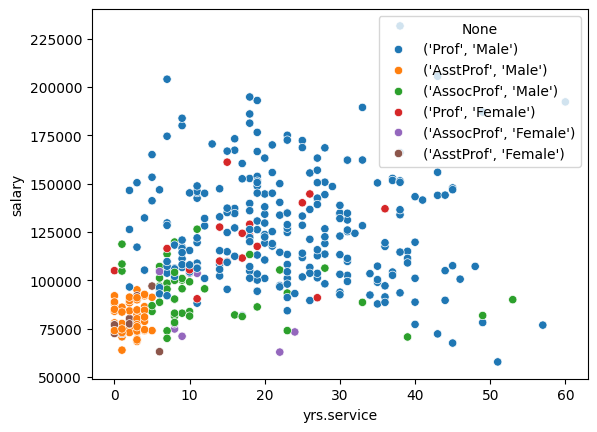

In [ ]:
sns.scatterplot(x=df['yrs.service'],
                y=df['salary'],
                hue=df[['rank', 'sex']].apply(tuple, axis=1))

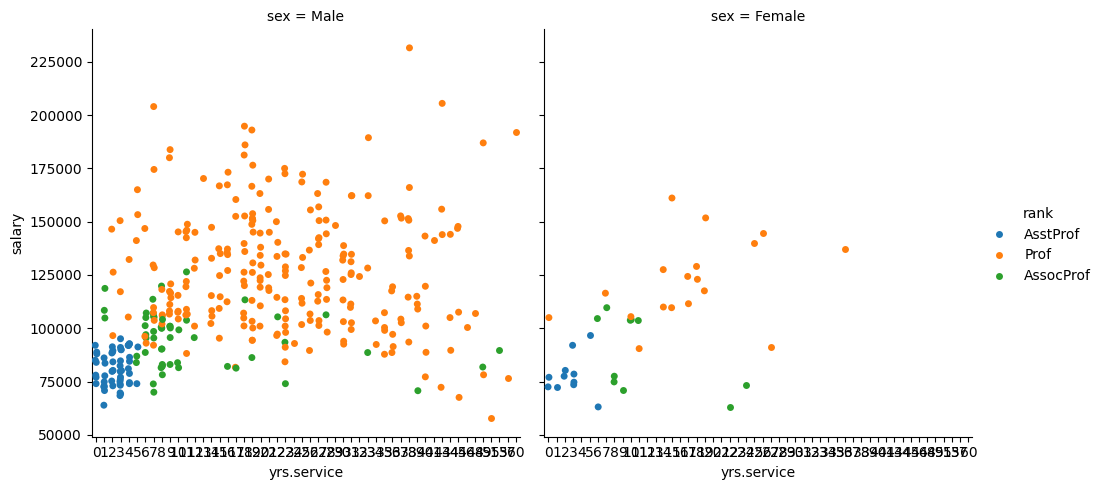

In [ ]:
sns.catplot(x=df['yrs.service'],
            y=df['salary'],
            hue=df['rank'],
            col=df['sex'])

<Axes: xlabel='yrs.service', ylabel='salary'>

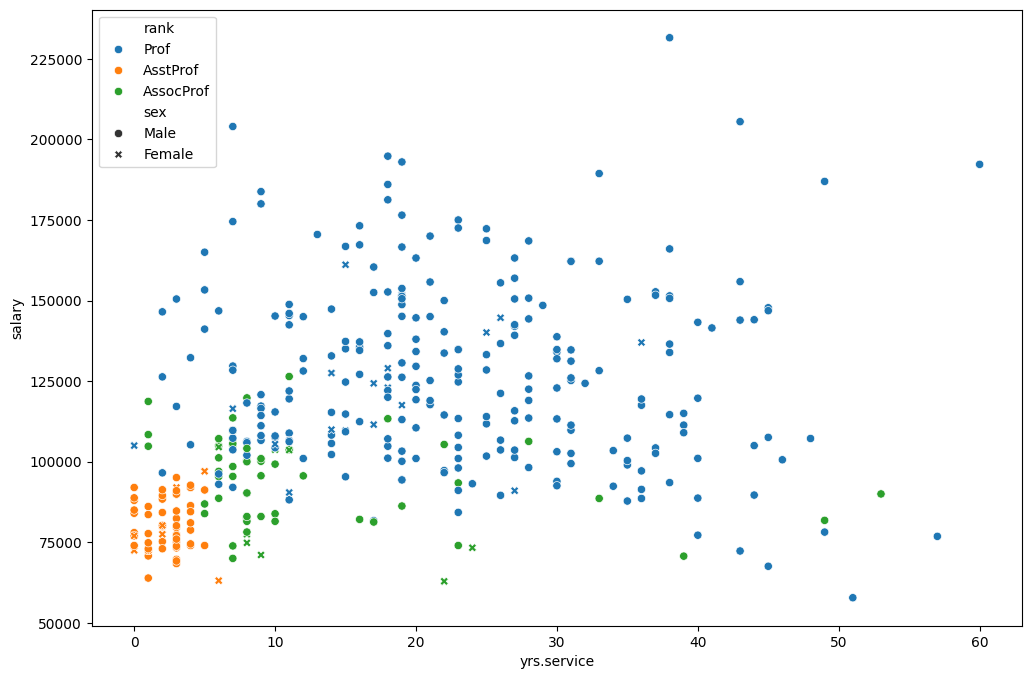

In [ ]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x=df['yrs.service'],
                y=df['salary'],
                hue=df['rank'],
                style=df['sex'])

<Axes: xlabel='rank', ylabel='salary'>

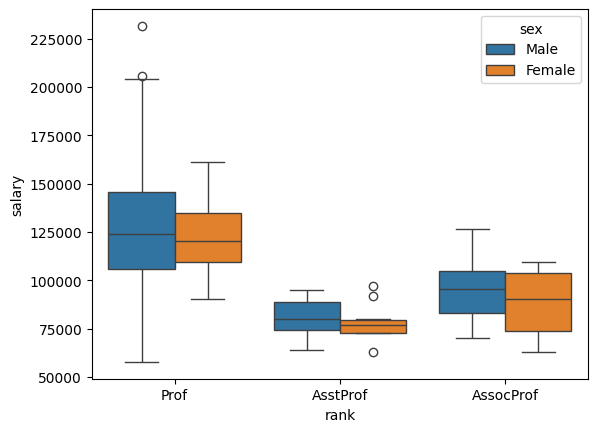

In [ ]:
sns.boxplot(x=df['rank'],
            y=df['salary'],
            hue=df['sex'])

In [ ]:
# Criar a base
df = pd.DataFrame({
    'x' : np.random.normal(10, 1.2, 20000),
    'y' : np.random.normal(10, 1.2, 20000),
    'group' : np.repeat('A', 20000)
})

tmp1 = pd.DataFrame({
    'x' : np.random.normal(14.5, 1.2, 20000),
    'y' : np.random.normal(14.5, 1.2, 20000),
    'group' : np.repeat('B', 20000)
})

tmp2 = pd.DataFrame({
    'x' : np.random.normal(9.5, 1.5, 20000),
    'y' : np.random.normal(15.5, 1.5, 20000),
    'group' : np.repeat('C', 20000)
})

# concatenating the data
df = pd.concat([df, tmp1, tmp2])


In [ ]:
df

,x,y,group
0,11.723109,9.678878,A
1,10.148008,10.060257,A
2,8.566994,10.634053,A
3,9.979112,9.143254,A
4,11.507984,9.358316,A
...,...,...,...
19995,8.377957,14.414713,C
19996,7.119474,16.369712,C
19997,8.052804,13.368507,C
19998,9.453992,17.774354,C


<Axes: xlabel='x', ylabel='y'>

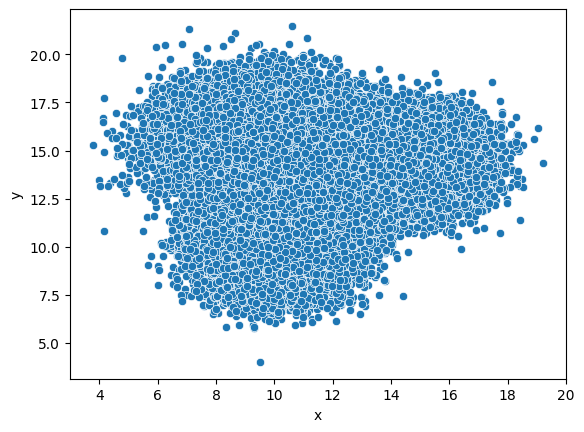

In [ ]:
sns.scatterplot(x=df['x'], y=df['y'])

<Axes: xlabel='x', ylabel='y'>

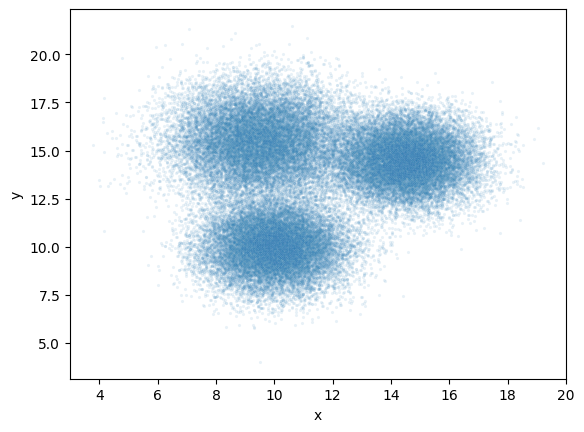

In [ ]:
sns.scatterplot(x=df['x'], y=df['y'], s=5, alpha=0.1)

<Axes: xlabel='x', ylabel='y'>

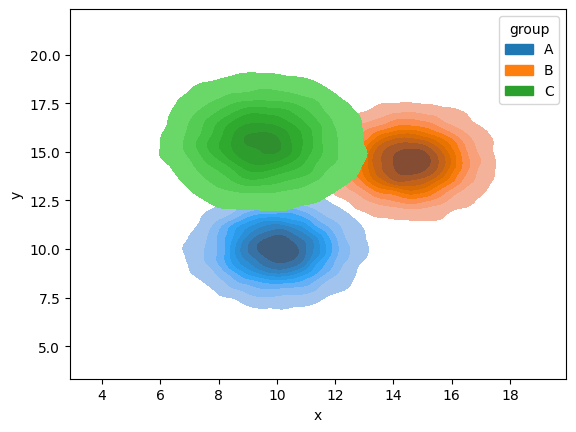

In [ ]:
# densidade
sns.kdeplot(x=df['x'], y=df['y'], fill=True, hue=df['group'])

<Axes: xlabel='x', ylabel='y'>

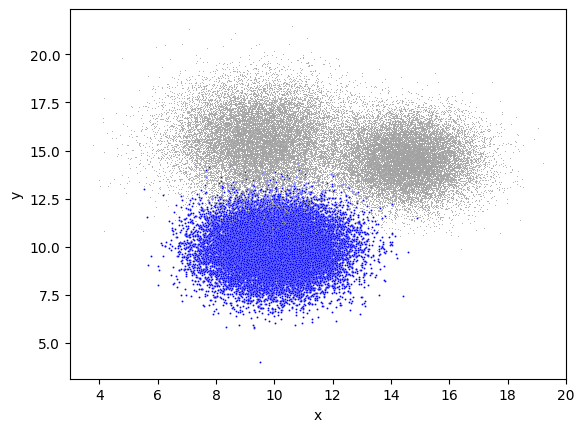

In [ ]:
# Plotando apenas o grupo A com uma cor diferente
df_a = df[df['group'] == 'A']
df_resto = df[df['group'] != 'A']
sns.scatterplot(x=df_a['x'], y=df_a['y'], color='blue', s=2)
sns.scatterplot(x=df_resto['x'], y=df_resto['y'], color='gray', s=0.5)




#### **Atividade**

In [ ]:
df_kobe = pd.read_csv('https://www.dropbox.com/s/m1e44xinrkn99qq/kobe_shots.csv?dl=1')
df_kobe.head(5)

,action_type,combined_shot_type,game_event_id,game_id,lat,loc_x,loc_y,lon,minutes_remaining,period,...,shot_type,shot_zone_area,shot_zone_basic,shot_zone_range,team_id,team_name,game_date,matchup,opponent,shot_id
0,Jump Shot,Jump Shot,10,20000012,33.9723,167,72,-118.1028,10,1,...,2PT Field Goal,Right Side(R),Mid-Range,16-24 ft.,1610612747,Los Angeles Lakers,2000-10-31,LAL @ POR,POR,1
1,Jump Shot,Jump Shot,12,20000012,34.0443,-157,0,-118.4268,10,1,...,2PT Field Goal,Left Side(L),Mid-Range,8-16 ft.,1610612747,Los Angeles Lakers,2000-10-31,LAL @ POR,POR,2
2,Jump Shot,Jump Shot,35,20000012,33.9093,-101,135,-118.3708,7,1,...,2PT Field Goal,Left Side Center(LC),Mid-Range,16-24 ft.,1610612747,Los Angeles Lakers,2000-10-31,LAL @ POR,POR,3
3,Jump Shot,Jump Shot,43,20000012,33.8693,138,175,-118.1318,6,1,...,2PT Field Goal,Right Side Center(RC),Mid-Range,16-24 ft.,1610612747,Los Angeles Lakers,2000-10-31,LAL @ POR,POR,4
4,Driving Dunk Shot,Dunk,155,20000012,34.0443,0,0,-118.2698,6,2,...,2PT Field Goal,Center(C),Restricted Area,Less Than 8 ft.,1610612747,Los Angeles Lakers,2000-10-31,LAL @ POR,POR,5


In [ ]:
df_kobe.shape

(30697, 25)

In [ ]:
df_kobe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30697 entries, 0 to 30696
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   action_type         30697 non-null  object 
 1   combined_shot_type  30697 non-null  object 
 2   game_event_id       30697 non-null  int64  
 3   game_id             30697 non-null  int64  
 4   lat                 30697 non-null  float64
 5   loc_x               30697 non-null  int64  
 6   loc_y               30697 non-null  int64  
 7   lon                 30697 non-null  float64
 8   minutes_remaining   30697 non-null  int64  
 9   period              30697 non-null  int64  
 10  playoffs            30697 non-null  int64  
 11  season              30697 non-null  object 
 12  seconds_remaining   30697 non-null  int64  
 13  shot_distance       30697 non-null  int64  
 14  shot_made_flag      25697 non-null  float64
 15  shot_type           30697 non-null  object 
 16  shot

In [ ]:
df_kobe.isnull().sum()

,0
action_type,0
combined_shot_type,0
game_event_id,0
game_id,0
lat,0
loc_x,0
loc_y,0
lon,0
minutes_remaining,0
period,0


In [ ]:
df_kobe.columns

Index(['action_type', 'combined_shot_type', 'game_event_id', 'game_id', 'lat',
       'loc_x', 'loc_y', 'lon', 'minutes_remaining', 'period', 'playoffs',
       'season', 'seconds_remaining', 'shot_distance', 'shot_made_flag',
       'shot_type', 'shot_zone_area', 'shot_zone_basic', 'shot_zone_range',
       'team_id', 'team_name', 'game_date', 'matchup', 'opponent', 'shot_id'],
      dtype='object')

**Tentativas de arremessos**

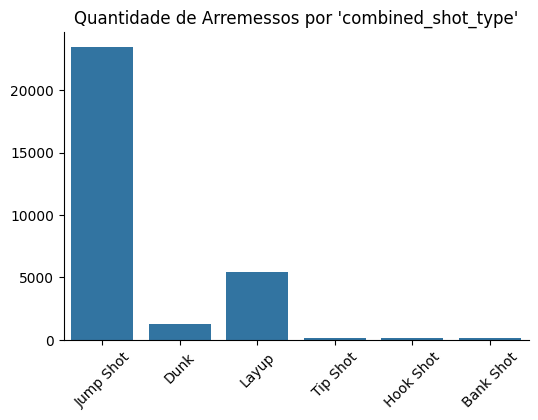

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x=df_kobe['combined_shot_type'])
plt.xticks(rotation=45)
plt.title("Quantidade de Arremessos por 'combined_shot_type'")
plt.xlabel("")
plt.ylabel("")
sns.despine()

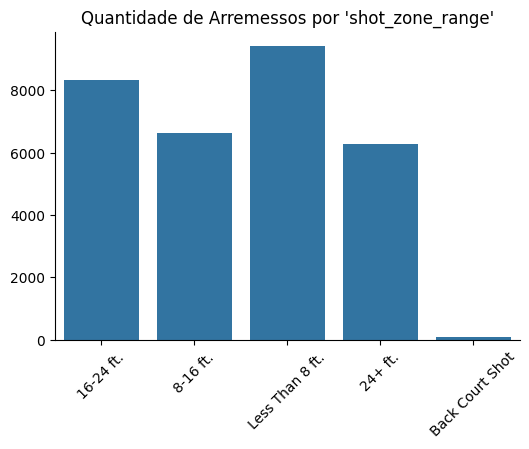

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x=df_kobe['shot_zone_range'])
plt.xticks(rotation=45)
plt.title("Quantidade de Arremessos por 'shot_zone_range'")
plt.xlabel("")
plt.ylabel("")
sns.despine()

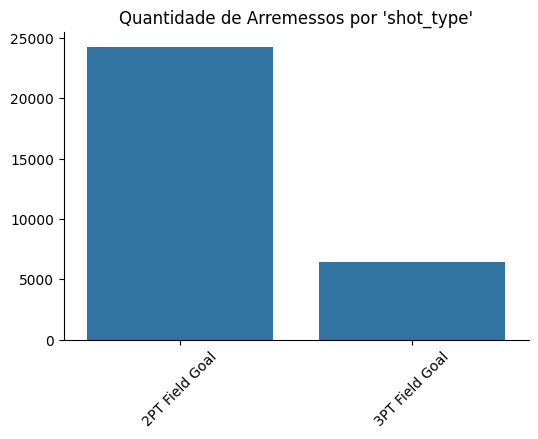

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x=df_kobe['shot_type'])
plt.xticks(rotation=45)
plt.title("Quantidade de Arremessos por 'shot_type'")
plt.xlabel("")
plt.ylabel("")
sns.despine()

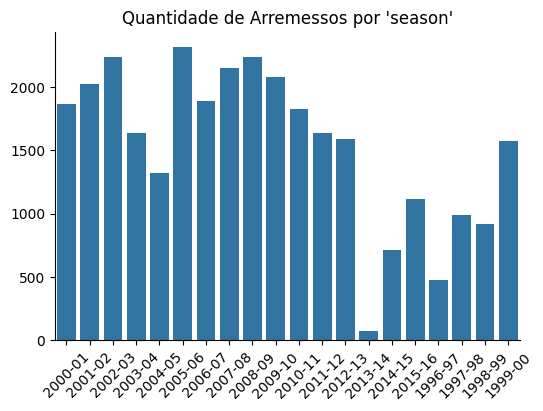

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x=df_kobe['season'])
plt.xticks(rotation=45)
plt.title("Quantidade de Arremessos por 'season'")
plt.xlabel("")
plt.ylabel("")
sns.despine()

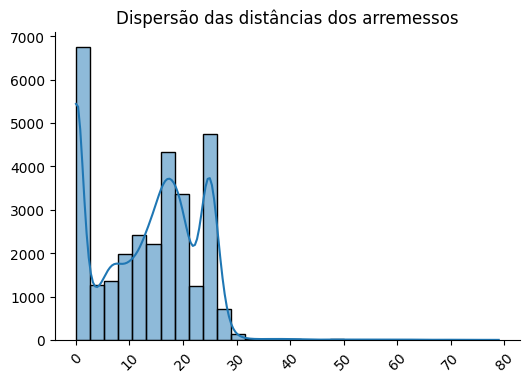

In [ ]:
plt.figure(figsize=(6, 4))
sns.histplot(x=df_kobe['shot_distance'], bins=30, kde=True)
plt.xticks(rotation=45)
plt.title("Dispersão das distâncias dos arremessos")
plt.xlabel("")
plt.ylabel("")
sns.despine()

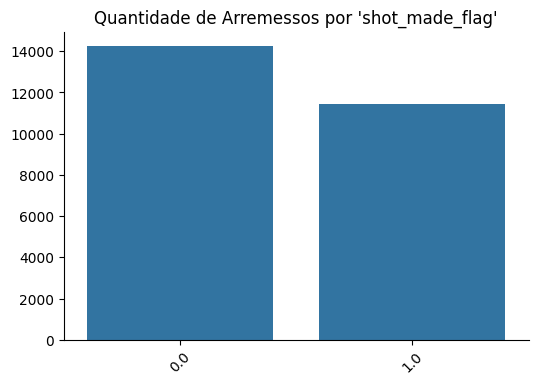

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x=df_kobe['shot_made_flag'])
plt.xticks(rotation=45)
plt.title("Quantidade de Arremessos por 'shot_made_flag'")
plt.xlabel("")
plt.ylabel("")
sns.despine()

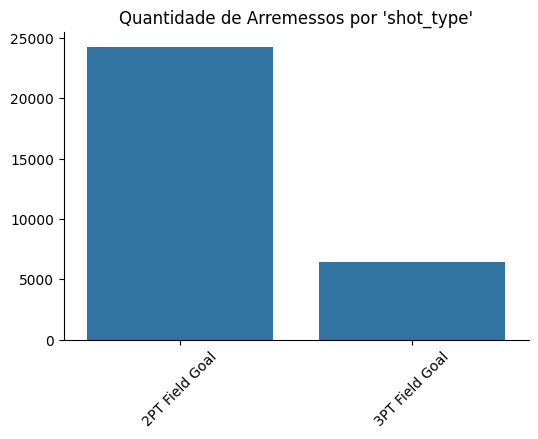

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x=df_kobe['shot_type'])
plt.xticks(rotation=45)
plt.title("Quantidade de Arremessos por 'shot_type'")
plt.xlabel("")
plt.ylabel("")
sns.despine()

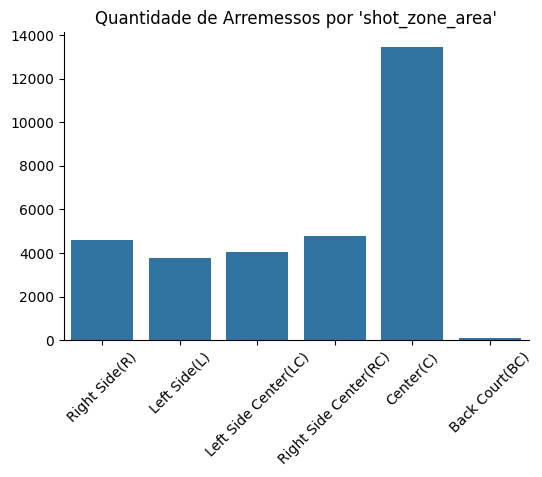

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x=df_kobe['shot_zone_area'])
plt.xticks(rotation=45)
plt.title("Quantidade de Arremessos por 'shot_zone_area'")
plt.xlabel("")
plt.ylabel("")
sns.despine()

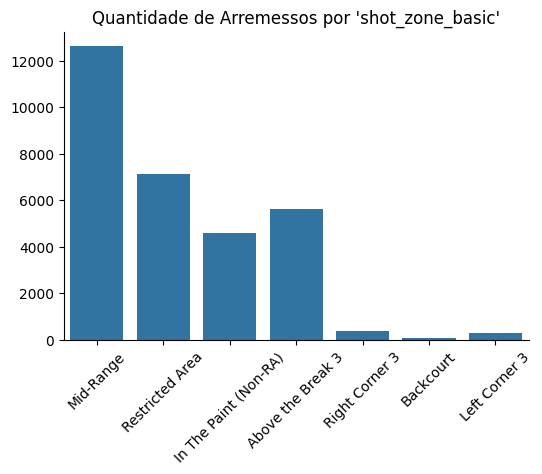

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x=df_kobe['shot_zone_basic'])
plt.xticks(rotation=45)
plt.title("Quantidade de Arremessos por 'shot_zone_basic'")
plt.xlabel("")
plt.ylabel("")
sns.despine()

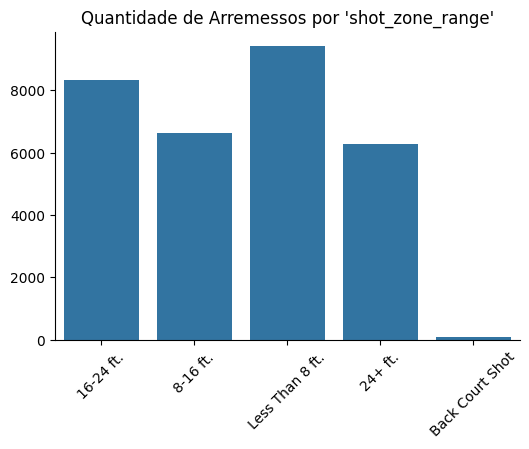

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x=df_kobe['shot_zone_range'])
plt.xticks(rotation=45)
plt.title("Quantidade de Arremessos por 'shot_zone_range'")
plt.xlabel("")
plt.ylabel("")
sns.despine()

**Anlálises Multivariadas**

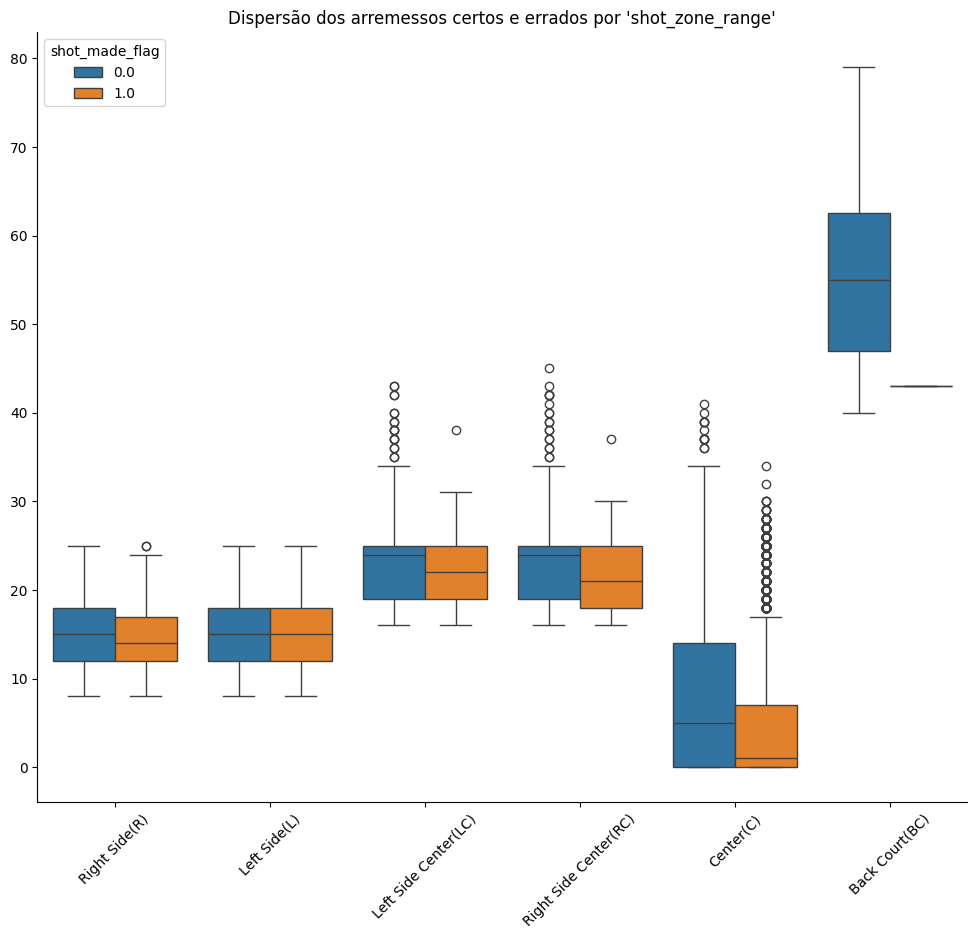

In [ ]:
plt.figure(figsize=(12, 10))
sns.boxplot(x=df_kobe['shot_zone_area'], y=df_kobe['shot_distance'], hue=df_kobe['shot_made_flag'])
plt.xticks(rotation=45)
plt.title("Dispersão dos arremessos certos e errados por 'shot_zone_range'")
plt.xlabel("")
plt.ylabel("")
sns.despine()

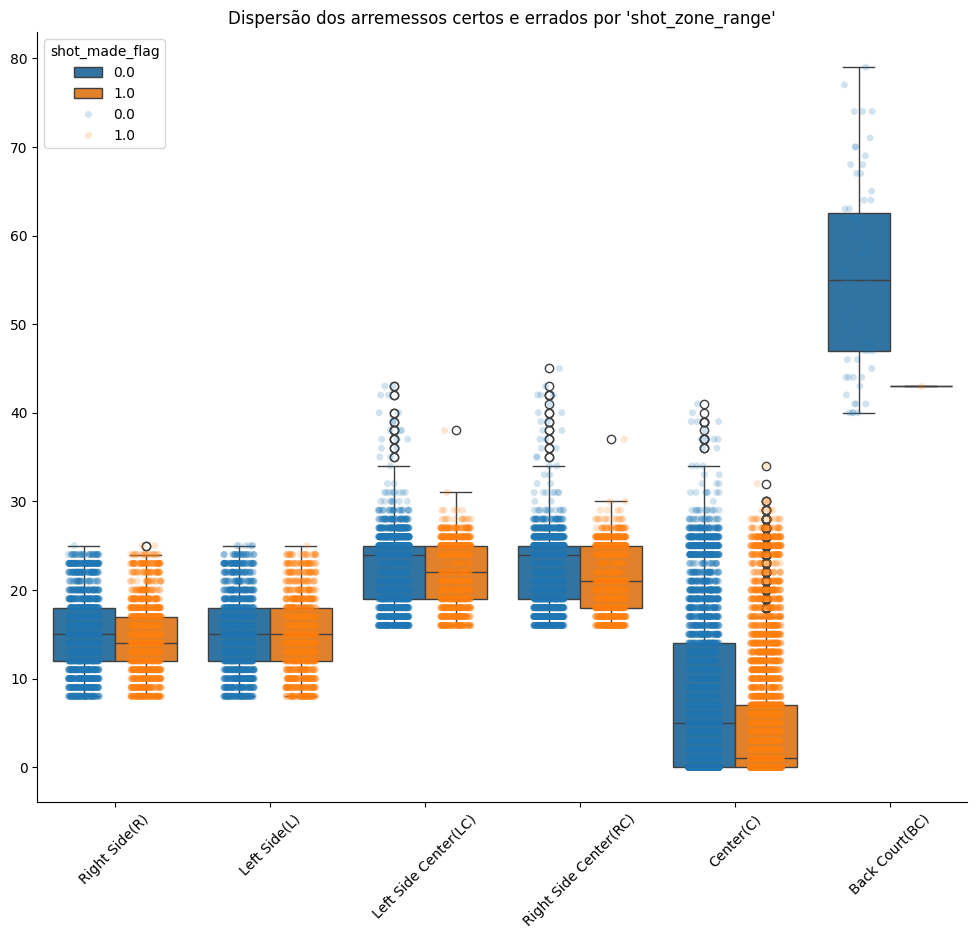

In [ ]:
plt.figure(figsize=(12, 10))
sns.boxplot(x=df_kobe['shot_zone_area'], y=df_kobe['shot_distance'], hue=df_kobe['shot_made_flag'])
sns.stripplot(x=df_kobe['shot_zone_area'], y=df_kobe['shot_distance'], hue=df_kobe['shot_made_flag'], jitter=0.2, dodge=True, alpha=0.2)
plt.xticks(rotation=45)
plt.title("Dispersão dos arremessos certos e errados por 'shot_zone_range'")
plt.xlabel("")
plt.ylabel("")
sns.despine()

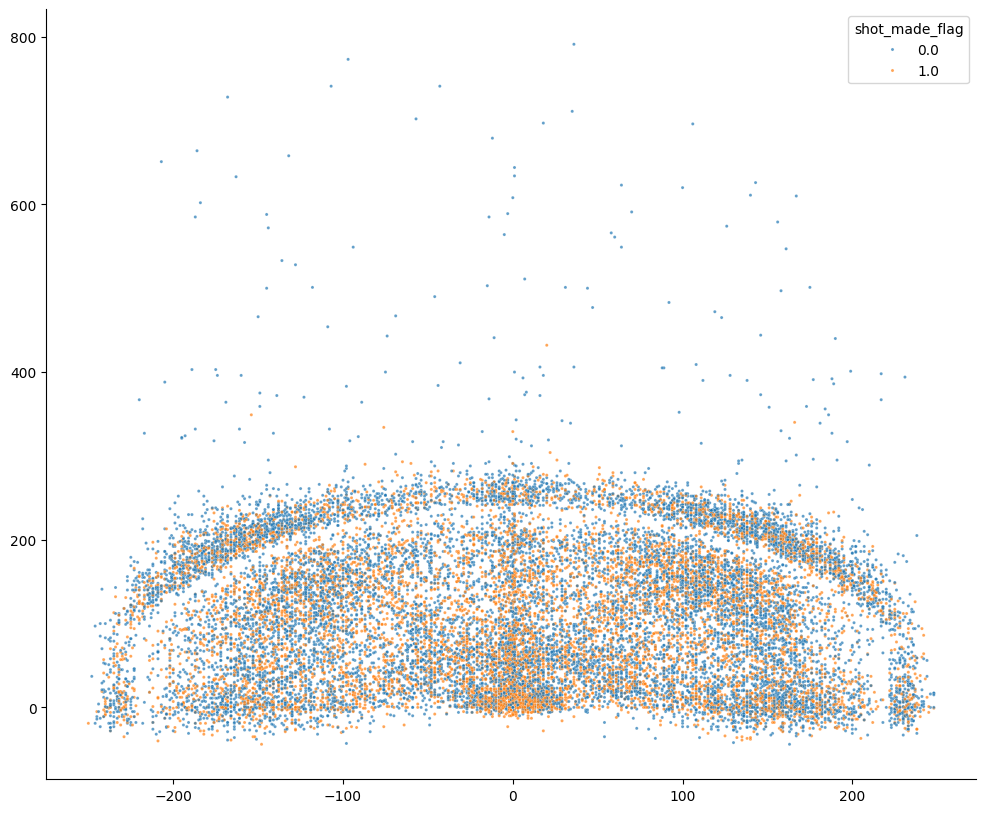

In [ ]:
plt.figure(figsize=(12, 10))
sns.scatterplot(x=df_kobe['loc_x'], y=df_kobe['loc_y'], hue=df_kobe['shot_made_flag'], s=5, alpha=0.7)
plt.xlabel("")
plt.ylabel("")
sns.despine()

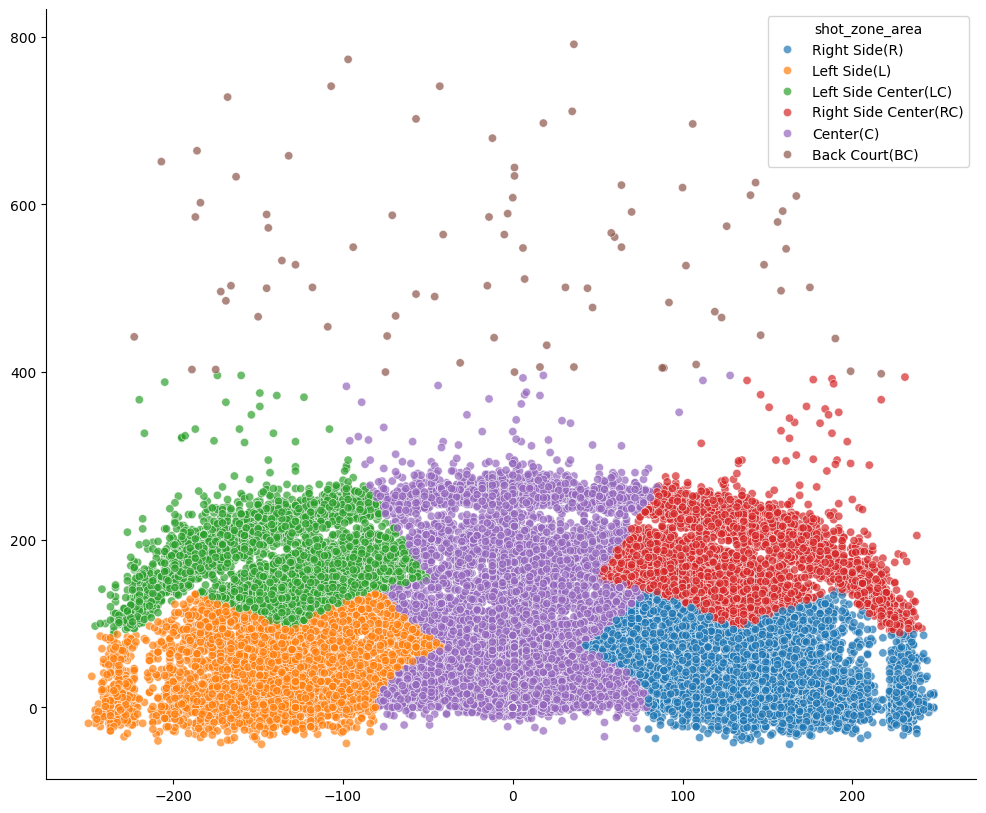

In [ ]:
plt.figure(figsize=(12, 10))
sns.scatterplot(x=df_kobe['loc_x'], y=df_kobe['loc_y'], hue=df_kobe['shot_zone_area'], alpha=0.7)
plt.xlabel("")
plt.ylabel("")
sns.despine()

<Figure size 1200x1000 with 0 Axes>

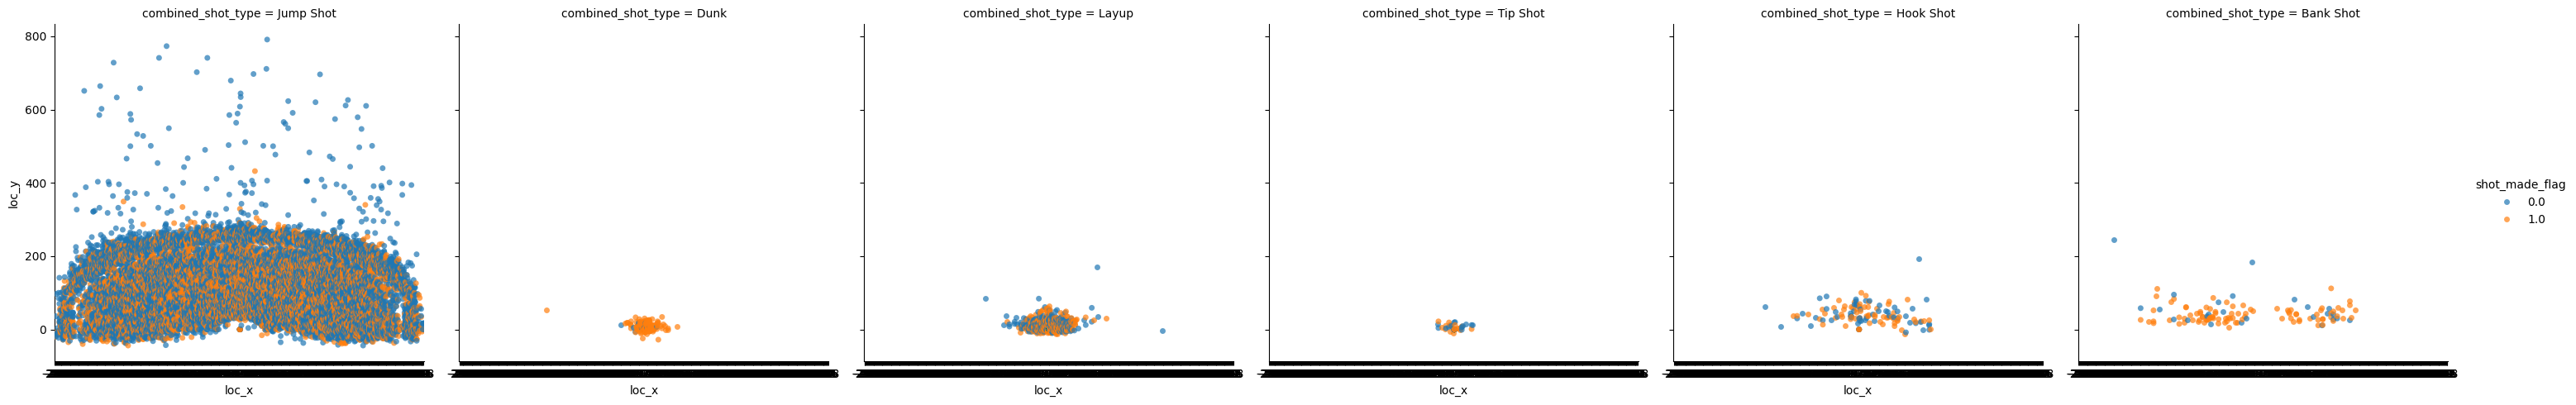

In [ ]:
plt.figure(figsize=(12, 10))
sns.catplot(x=df_kobe['loc_x'], y=df_kobe['loc_y'], hue=df_kobe['shot_made_flag'], col=df_kobe['combined_shot_type'], alpha=0.7)
plt.xlabel("")
plt.ylabel("")
sns.despine()

In [ ]:
df_kobe_semnull = df_kobe.dropna(subset='shot_made_flag')
df_kobe_semnull.shape

(25697, 25)

### Tipo de arremesso


In [ ]:
tx_acerto_por_tipo_arremesso = df_kobe_semnull.groupby(['shot_type'])['shot_made_flag'].value_counts().unstack().reset_index()
tx_acerto_por_tipo_arremesso.rename(columns={0:'errou', 1:'acertou'}, inplace=True)

In [ ]:
tx_acerto_por_tipo_arremesso['tx_acerto'] = tx_acerto_por_tipo_arremesso['acertou'] / (tx_acerto_por_tipo_arremesso['errou'] + tx_acerto_por_tipo_arremesso['acertou'])

<Axes: xlabel='shot_type', ylabel='count'>

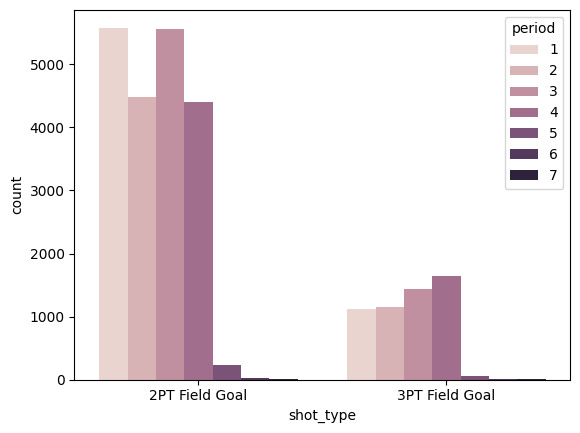

In [ ]:
sns.countplot(data=df_kobe_semnull, x='shot_type', hue='period')

<Axes: xlabel='shot_type', ylabel='tx_acerto'>

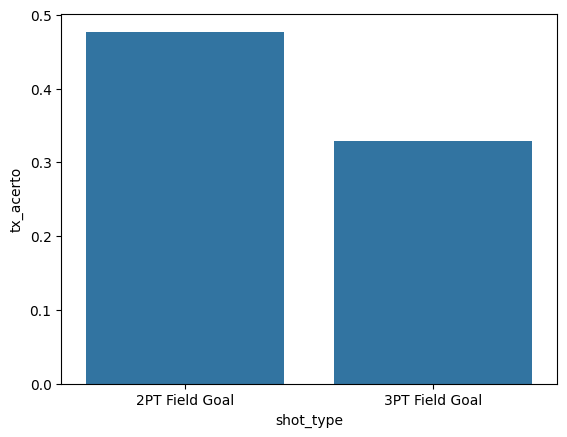

In [ ]:
sns.barplot(x=tx_acerto_por_tipo_arremesso['shot_type'], y=tx_acerto_por_tipo_arremesso['tx_acerto'])

### Area do Arremesso

In [ ]:
tx_acerto_por_zona_do_arremesso = df_kobe_semnull.groupby(['shot_zone_area'])['shot_made_flag'].value_counts().unstack().reset_index()
tx_acerto_por_zona_do_arremesso.rename(columns={0:'errou', 1:'acertou'}, inplace=True)

In [ ]:
tx_acerto_por_zona_do_arremesso['tx_acerto'] = tx_acerto_por_zona_do_arremesso['acertou'] / (tx_acerto_por_zona_do_arremesso['errou'] + tx_acerto_por_zona_do_arremesso['acertou'])

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'Back Court(BC)'),
  Text(1, 0, 'Center(C)'),
  Text(2, 0, 'Left Side Center(LC)'),
  Text(3, 0, 'Left Side(L)'),
  Text(4, 0, 'Right Side Center(RC)'),
  Text(5, 0, 'Right Side(R)')])

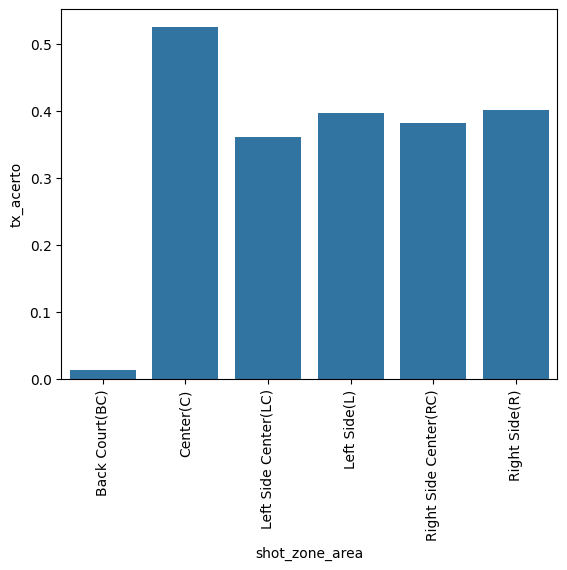

In [ ]:
sns.barplot(x=tx_acerto_por_zona_do_arremesso['shot_zone_area'], y=tx_acerto_por_zona_do_arremesso['tx_acerto'])
plt.xticks(rotation=90)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [Text(0, 0, '2000-01'),
  Text(1, 0, '2001-02'),
  Text(2, 0, '2002-03'),
  Text(3, 0, '2003-04'),
  Text(4, 0, '2004-05'),
  Text(5, 0, '2005-06'),
  Text(6, 0, '2006-07'),
  Text(7, 0, '2007-08'),
  Text(8, 0, '2008-09'),
  Text(9, 0, '2009-10'),
  Text(10, 0, '2010-11'),
  Text(11, 0, '2011-12'),
  Text(12, 0, '2012-13'),
  Text(13, 0, '2013-14'),
  Text(14, 0, '2014-15'),
  Text(15, 0, '2015-16'),
  Text(16, 0, '1996-97'),
  Text(17, 0, '1997-98'),
  Text(18, 0, '1998-99'),
  Text(19, 0, '1999-00')])

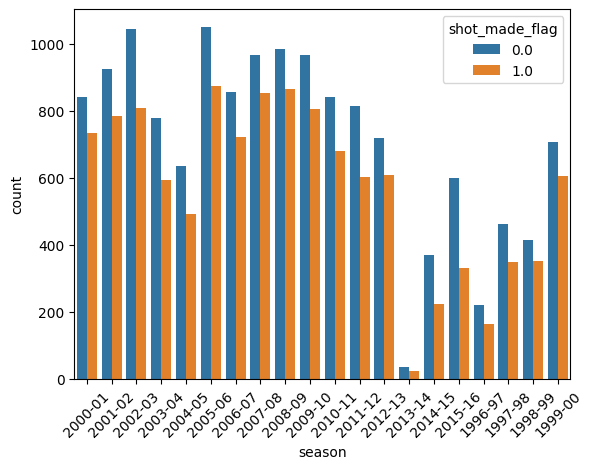

In [ ]:
sns.countplot(x=df_kobe_semnull['season'], hue=df_kobe_semnull['shot_made_flag'])
plt.xticks(rotation=45)

In [ ]:
arremessos_por_area = df_kobe.groupby('shot_zone_area')['shot_type'].value_counts().unstack().reset_index()
arremessos_por_area

shot_type,shot_zone_area,2PT Field Goal,3PT Field Goal
0,Back Court(BC),1,82
1,Center(C),12355,1100
2,Left Side Center(LC),1842,2202
3,Left Side(L),3467,284
4,Right Side Center(RC),2409,2367
5,Right Side(R),4197,391


In [ ]:
arremessos_por_area = pd.crosstab(df_kobe['shot_type'], df_kobe['shot_zone_area'])
arremessos_por_area

shot_zone_area,Back Court(BC),Center(C),Left Side Center(LC),Left Side(L),Right Side Center(RC),Right Side(R)
shot_type,,,,,,
2PT Field Goal,1,12355,1842,3467,2409,4197
3PT Field Goal,82,1100,2202,284,2367,391


<Axes: xlabel='shot_type'>

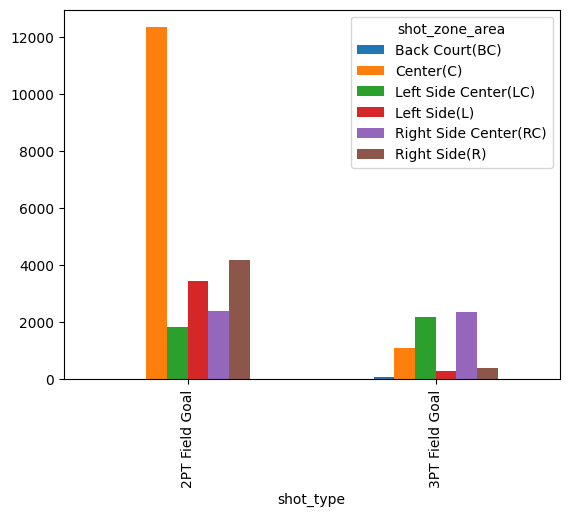

In [ ]:
arremessos_por_area.plot(kind='bar')

In [ ]:
df_kobe_semnull['shot_type'].unique()

array(['2PT Field Goal', '3PT Field Goal'], dtype=object)





#**Aula 4 - Correlações**


In [ ]:
from scipy import stats

In [ ]:
df = pd.read_csv('https://jpbarddal.github.io/assets/data/datascience/meses_producao_custo.csv')
df.head()

,Meses,litros,custo
0,Jan,20200,19000
1,Fev,16700,17000
2,Mar,14800,14000
3,Abr,16000,15000
4,Mai,12100,14000


Text(0, 0.5, '')

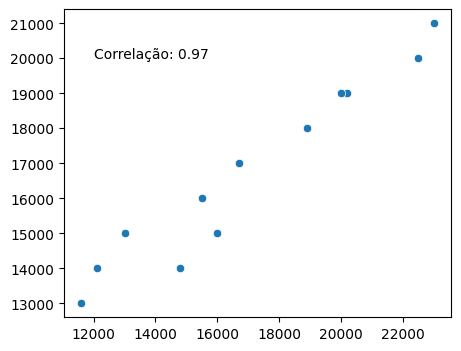

In [ ]:
plt.figure(figsize=(5, 4))
sns.scatterplot(x=df['litros'], y=df['custo'])
r, _ = stats.pearsonr(df['litros'], df['custo'])
plt.text(x=12_000, y=20_000, s=f'Correlação: {r:.2f}')
plt.xlabel("")
plt.ylabel("")

Text(0, 0.5, '')

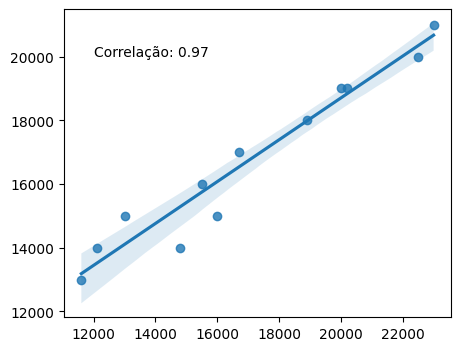

In [ ]:
plt.figure(figsize=(5, 4))
sns.regplot(x=df['litros'], y=df['custo'])
r, _ = stats.pearsonr(df['litros'], df['custo'])
plt.text(x=12_000, y=20_000, s=f'Correlação: {r:.2f}')
plt.xlabel("")
plt.ylabel("")

Text(37.722222222222214, 0.5, '')

<Figure size 500x400 with 0 Axes>

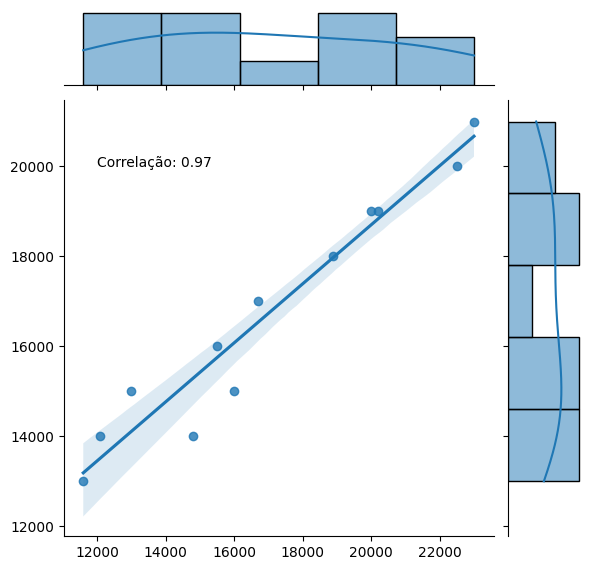

In [ ]:
plt.figure(figsize=(5, 4))
sns.jointplot(x=df['litros'], y=df['custo'], kind='reg')
r, _ = stats.pearsonr(df['litros'], df['custo'])
plt.text(x=12_000, y=20_000, s=f'Correlação: {r:.2f}')
plt.xlabel("")
plt.ylabel("")

Text(-2, 1.0, 'Pearson r = 0.00')

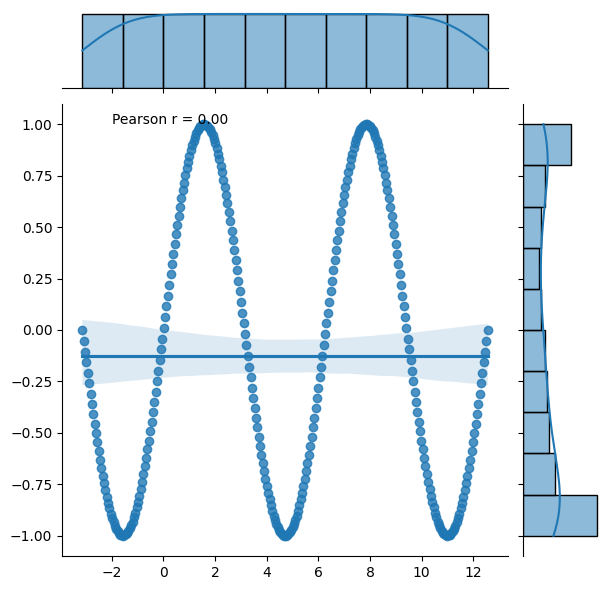

In [ ]:
x = np.linspace(-np.pi, 4*np.pi, 300)
y = np.sin(x)
sns.jointplot(x=x, y=y, kind='reg')
r, _ = stats.pearsonr(x, y)
plt.text(x=-2, y=1.0, s=f'Pearson r = {r:.2f}')


In [ ]:
df.select_dtypes(include='number').corr()

,litros,custo
litros,1.000000,0.969993
custo,0.969993,1.000000


In [ ]:
df_ommlbd = pd.read_csv('https://jpbarddal.github.io/assets/data/datascience/ommlbd_familiar.csv')
df_ommlbd = df_ommlbd.replace(-9999, np.nan)

In [ ]:
df_ommlbd.corr()

,HS_CPF,QTDPESSOASCASA,MENORRENDACASA,MAIORRENDACASA,SOMARENDACASA,MEDIARENDACASA,MAIORIDADECASA,MENORIDADECASA,MEDIAIDADECASA,INDICMENORDEIDADE,COBRANCABAIXOCASA,COBRANCAMEDIOCASA,COBRANCAALTACASA,SEGMENTACAOFINBAIXACASA,SEGMENTACAOFINMEDIACASA,SEGMENTACAOALTACASA,BOLSAFAMILIACASA,FUNCIONARIOPUBLICOCASA
HS_CPF,1.000000,0.019929,-0.024549,-0.020831,-0.018844,-0.027608,0.041364,0.026502,0.035755,-0.034576,0.072836,0.014370,0.035500,0.127453,0.001258,0.001693,0.060586,0.000733
QTDPESSOASCASA,0.019929,1.000000,-0.183627,0.053948,0.252608,-0.103643,0.259603,-0.166085,-0.033299,0.115711,0.109687,0.033187,0.031315,0.078343,0.010212,0.002181,0.248071,0.078393
MENORRENDACASA,-0.024549,-0.183627,1.000000,0.352656,0.433097,0.615976,0.106155,0.269575,0.232897,-0.074302,0.012774,0.004359,-0.006413,-0.010084,-0.000067,0.008744,-0.226525,0.106405
MAIORRENDACASA,-0.020831,0.053948,0.352656,1.000000,0.923269,0.917403,0.219026,0.144396,0.218736,-0.040999,0.045489,0.015623,0.003079,0.004508,0.008445,0.004686,-0.208776,0.200532
SOMARENDACASA,-0.018844,0.252608,0.433097,0.923269,1.000000,0.880107,0.285825,0.145600,0.244595,-0.036681,0.073351,0.025266,0.010955,0.023593,0.011624,0.006083,-0.189434,0.230712
MEDIARENDACASA,-0.027608,-0.103643,0.615976,0.917403,0.880107,1.000000,0.198684,0.230392,0.269323,-0.072104,0.032249,0.011203,-0.002031,-0.006555,0.006487,0.006899,-0.257195,0.195284
MAIORIDADECASA,0.041364,0.259603,0.106155,0.219026,0.285825,0.198684,1.000000,0.489634,0.836517,-0.121856,0.064165,0.014462,0.016789,0.028294,0.007349,0.002348,-0.056346,0.083808
MENORIDADECASA,0.026502,-0.166085,0.269575,0.144396,0.145600,0.230392,0.489634,1.000000,0.844348,-0.227301,0.032271,0.008302,0.009470,0.001591,0.003308,-0.000865,-0.091464,0.031671
MEDIAIDADECASA,0.035755,-0.033299,0.232897,0.218736,0.244595,0.269323,0.836517,0.844348,1.000000,-0.218414,0.046645,0.010607,0.011476,0.009690,0.005007,0.001161,-0.121059,0.063364
INDICMENORDEIDADE,-0.034576,0.115711,-0.074302,-0.040999,-0.036681,-0.072104,-0.121856,-0.227301,-0.218414,1.000000,-0.017177,-0.003565,-0.004737,-0.014751,-0.003264,-0.002418,0.057522,-0.013577


<Axes: >

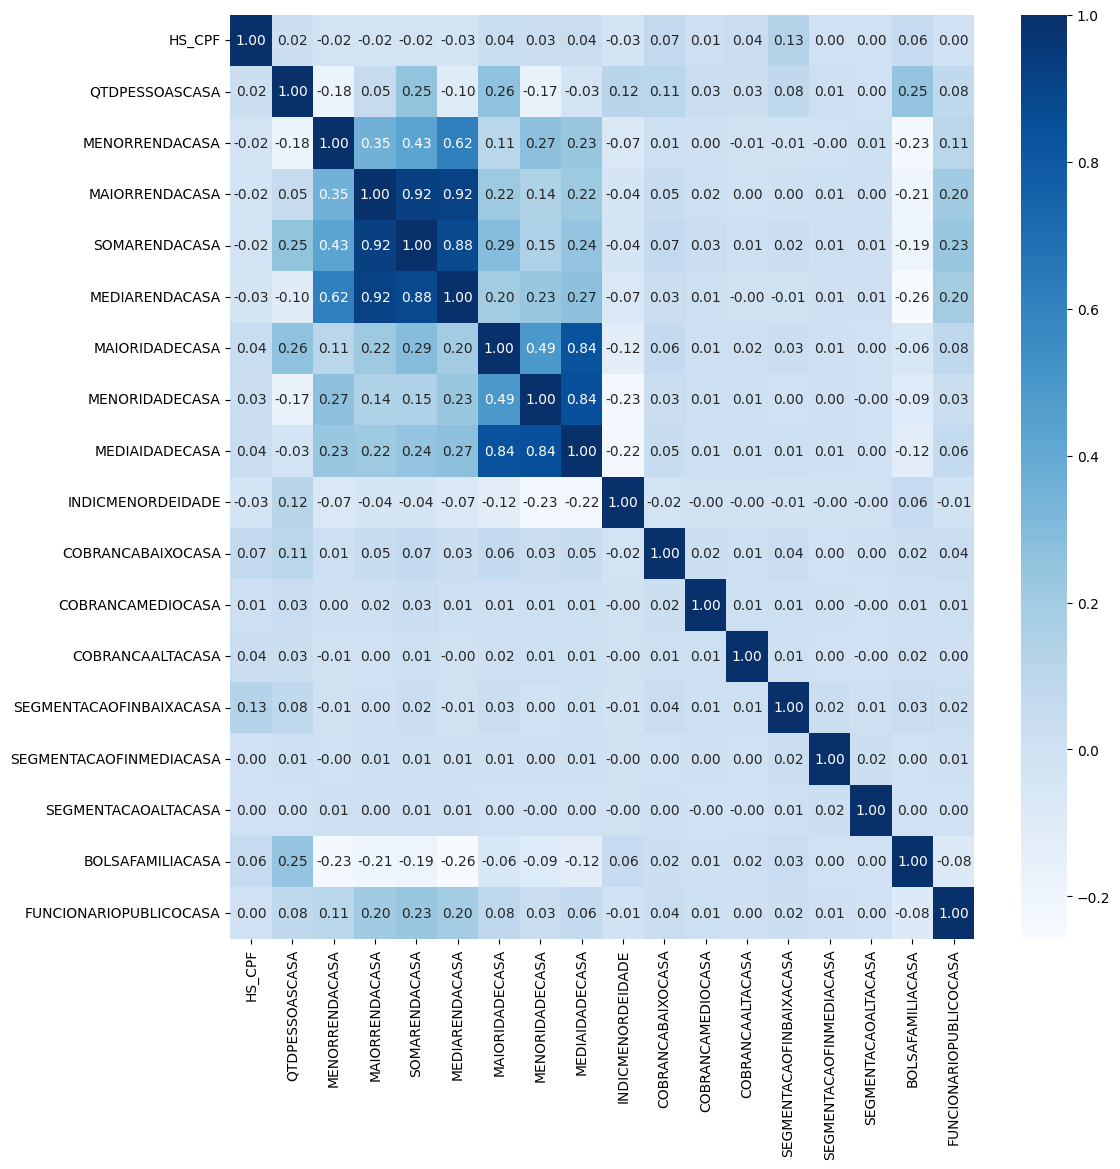

In [ ]:
correlacoes = df_ommlbd.corr()
plt.figure(figsize=(12, 12))
sns.heatmap(correlacoes,
            annot=True,
            fmt='.2f',
            cmap='Blues')

<Axes: >

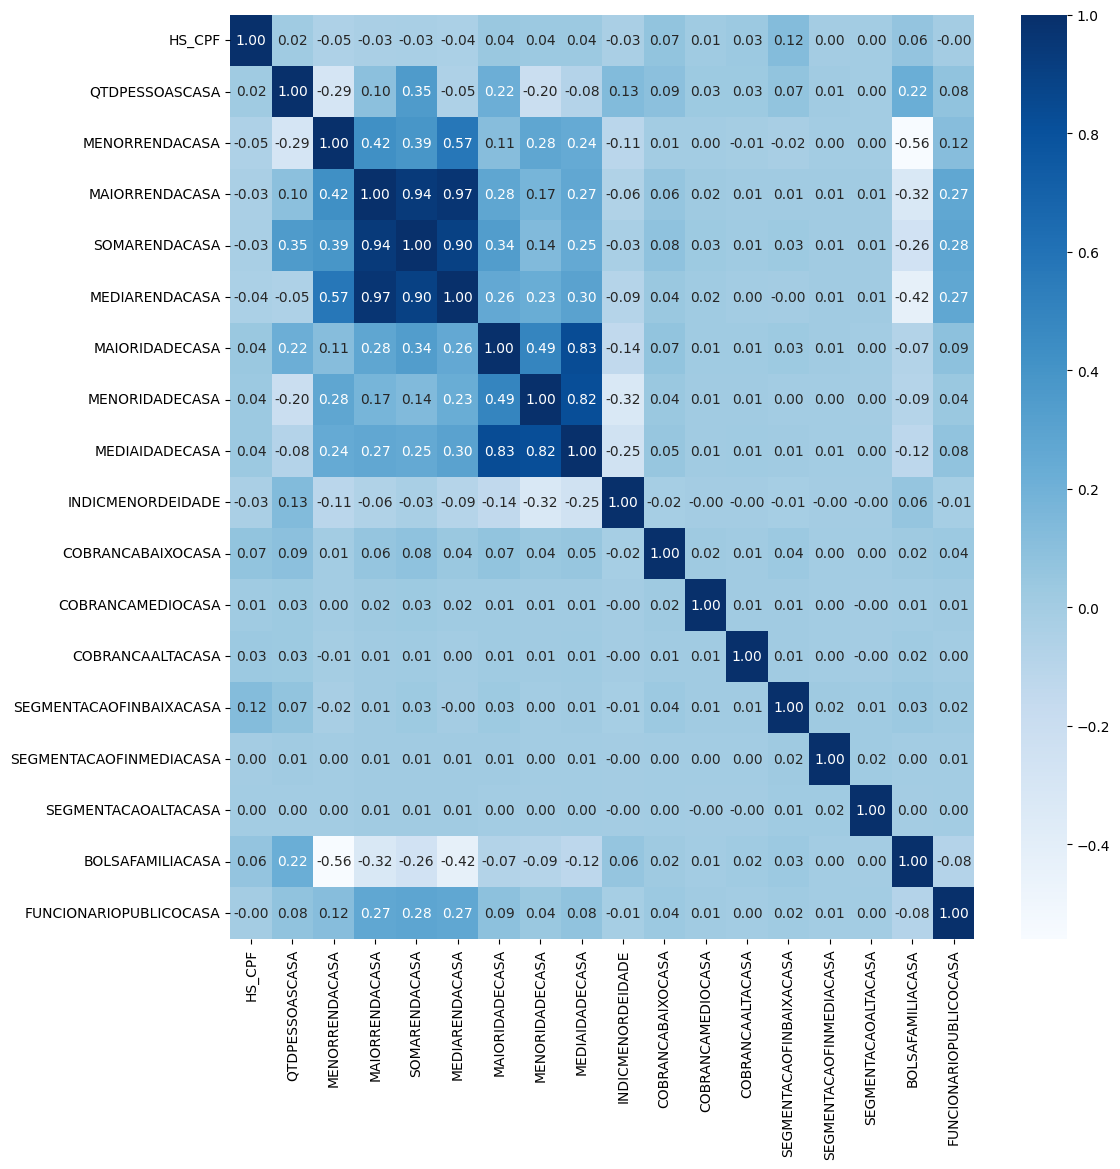

In [ ]:
correlacoes_spearman = df_ommlbd.corr(method='spearman')
plt.figure(figsize=(12, 12))
sns.heatmap(correlacoes_spearman,
            annot=True,
            fmt='.2f',
            cmap='Blues')

Relação entre variáves categóricas

In [ ]:
df_titanic = pd.read_csv('https://jpbarddal.github.io/assets/data/datascience/titanic.csv')
df_titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<Axes: xlabel='Survived', ylabel='Pclass'>

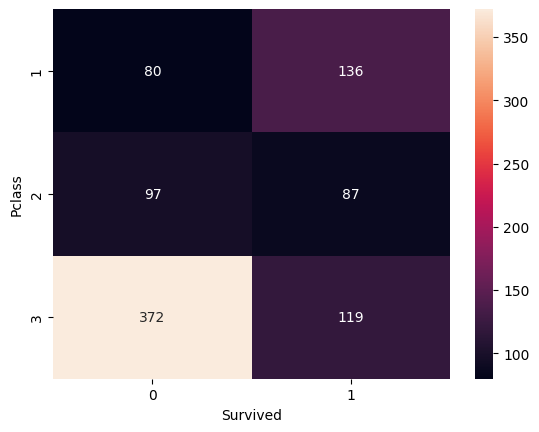

In [ ]:
# Relação entre sobreviventes e classe
ctab = pd.crosstab(df_titanic['Pclass'], df_titanic['Survived'])
sns.heatmap(ctab, annot=True, fmt='d')

<Axes: xlabel='Survived', ylabel='Pclass'>

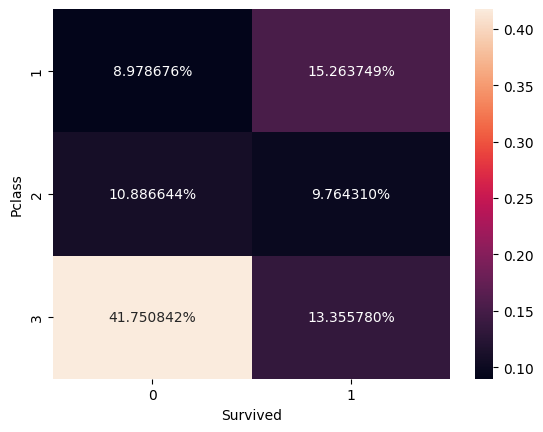

In [ ]:
# Normalização pelo todo
ctab = pd.crosstab(df_titanic['Pclass'], df_titanic['Survived'], normalize='all')
sns.heatmap(ctab, annot=True, fmt='%')

<Axes: xlabel='Survived', ylabel='Pclass'>

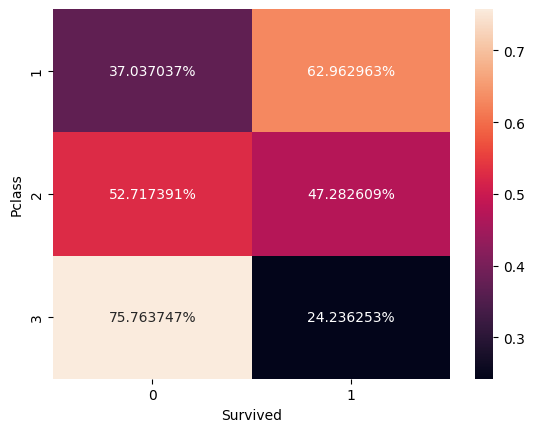

In [ ]:
# Normalização pela linha
ctab = pd.crosstab(df_titanic['Pclass'], df_titanic['Survived'], normalize='index')
sns.heatmap(ctab, annot=True, fmt='%')

<Axes: xlabel='Survived', ylabel='Pclass'>

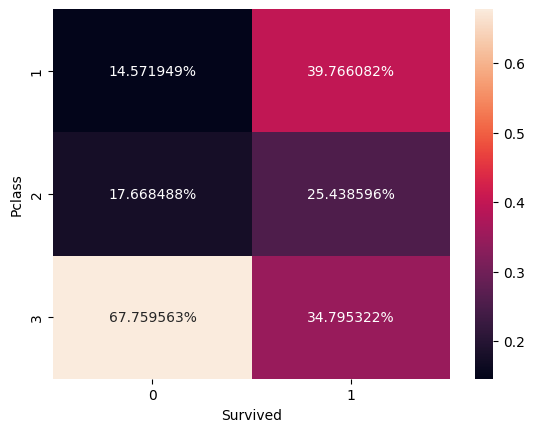

In [ ]:
# Normalização pela coluna
ctab = pd.crosstab(df_titanic['Pclass'], df_titanic['Survived'], normalize='columns')
sns.heatmap(ctab, annot=True, fmt='%')

<Axes: xlabel='Survived', ylabel='Sex'>

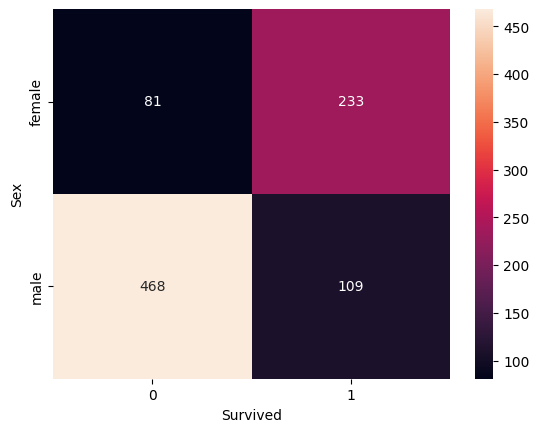

In [ ]:
# Relação entre sobrevivente e sexo
ctab = pd.crosstab(df_titanic['Sex'], df_titanic['Survived'])
sns.heatmap(ctab, annot=True, fmt='d')

<Axes: xlabel='Survived', ylabel='Sex'>

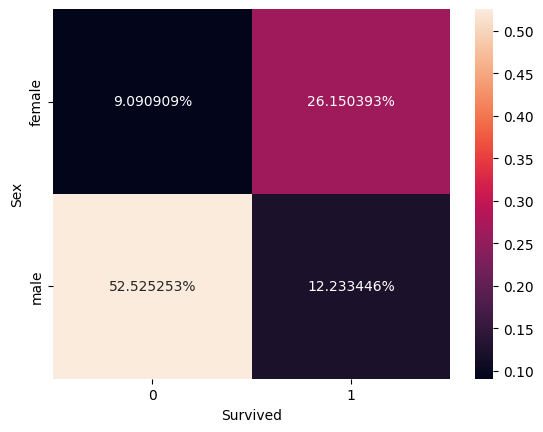

In [ ]:
# Normalização pelo todo
ctab = pd.crosstab(df_titanic['Sex'], df_titanic['Survived'], normalize='all')
sns.heatmap(ctab, annot=True, fmt='%')

<Axes: xlabel='Survived', ylabel='Sex'>

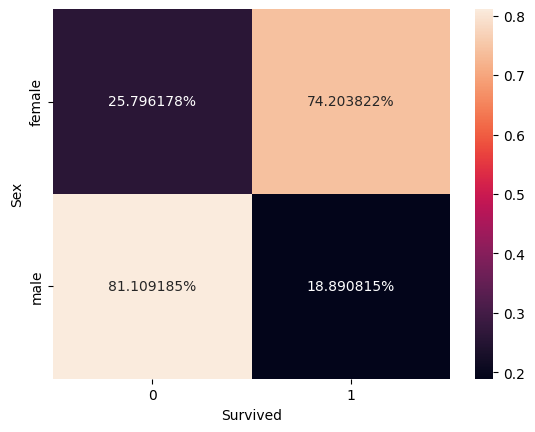

In [ ]:
# Normalização pela linha
ctab = pd.crosstab(df_titanic['Sex'], df_titanic['Survived'], normalize='index')
sns.heatmap(ctab, annot=True, fmt='%')

<Axes: xlabel='Survived', ylabel='Sex'>

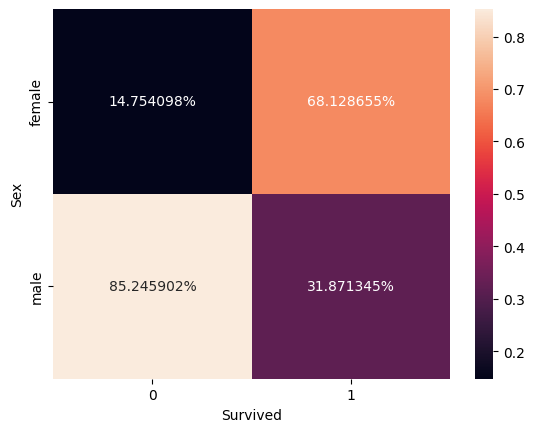

In [ ]:
# Normalização pela coluna
ctab = pd.crosstab(df_titanic['Sex'], df_titanic['Survived'], normalize='columns')
sns.heatmap(ctab, annot=True, fmt='%')

<Axes: xlabel='Survived', ylabel='Sex-Pclass'>

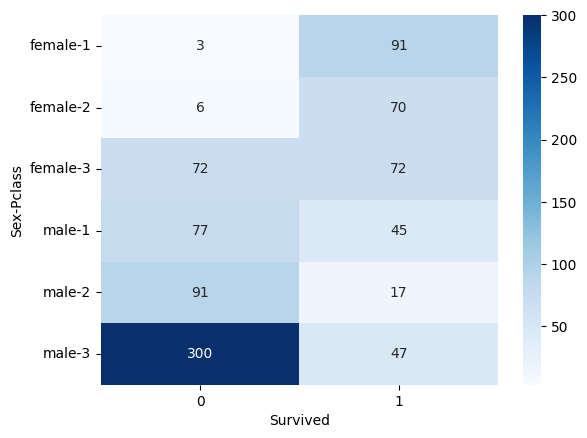

In [ ]:
# Considerando mais colunas
ctab = pd.crosstab([df_titanic['Sex'], df_titanic['Pclass']],
                   df_titanic['Survived'])
sns.heatmap(ctab, annot=True, fmt='d', cmap='Blues')

In [ ]:
# Relação entre sobrevivência e idade
# Adulto/criança
#df_titanic['Adulto_crianca'] = df_titanic['Age'] > 12
df_titanic['Adulto_crianca'] = df_titanic['Age'].apply(lambda x: 'Adulto' if x > 12 else 'Criança')

In [ ]:
# Faixa de idade
def faixa_idade(x):
  if np.isnan(x):
    return 'Desconhecido'
  elif x <= 12:
    return 'Criança'
  elif x <= 18:
    return 'Adolescente'
  elif x <= 60:
    return 'Adulto'
  else:
    return 'Idoso'

df_titanic['Faixa_idade'] = df_titanic['Age'].apply(faixa_idade)

In [ ]:
# Outra forma
df_titanic['fx_cut'] = pd.cut(df_titanic['Age'],
                              bins=[0, 12, 18, 60, np.inf],
                              labels=['Criança', 'Adolescente', 'Adulto', 'Idoso'])
df_titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Adulto_crianca,Faixa_idade,fx_cut
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Adulto,Adulto,Adulto
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Adulto,Adulto,Adulto
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Adulto,Adulto,Adulto
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Adulto,Adulto,Adulto
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Adulto,Adulto,Adulto


<Axes: xlabel='Survived', ylabel='fx_cut'>

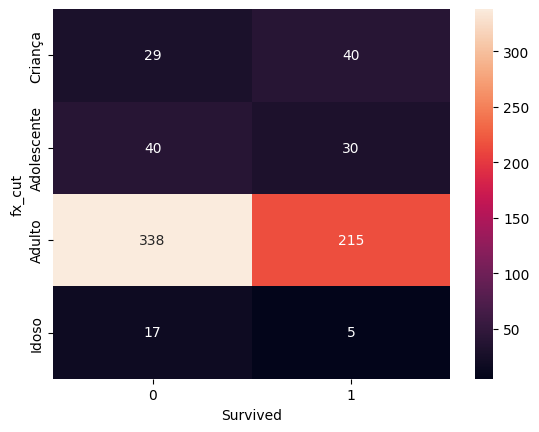

In [ ]:
ctab = pd.crosstab(df_titanic['fx_cut'],
                   df_titanic['Survived'])
sns.heatmap(ctab, annot=True, fmt='d')

# **Aula 05 - Atividade**

In [ ]:
df = pd.read_csv('https://jpbarddal.github.io/assets/data/datascience/california_housing_train.csv')
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0
...,...,...,...,...,...,...,...,...,...
16995,-124.26,40.58,52.0,2217.0,394.0,907.0,369.0,2.3571,111400.0
16996,-124.27,40.69,36.0,2349.0,528.0,1194.0,465.0,2.5179,79000.0
16997,-124.30,41.84,17.0,2677.0,531.0,1244.0,456.0,3.0313,103600.0
16998,-124.30,41.80,19.0,2672.0,552.0,1298.0,478.0,1.9797,85800.0


1. **longitude:** Uma medida de quão longe está a oeste de uma casa; um valor mais alto é mais a oeste
2. **latitude:** Uma medida de quão ao norte uma casa está; um valor mais alto é mais ao norte
3. **housingMedianAge**: Idade média de uma casa dentro de uma área; um número menor é um edifício
mais novo
4. **totalRooms:** Número total de cômodos dentro de uma área.
5. **totalBedrooms**: Número total de quartos dentro de uma área.
6. **population:** Número total de pessoas que residem dentro de uma área.
7. **households:** Número total de famílias, para uma área.
8. **medianIncome:** Renda média para famílias dentro de uma área de casas (medida em dezenas de milhares de dólares)
9. **medianHouseValue:** Valor médio da casa dentro de uma área (medido em dólares)

In [ ]:
df.shape

(17000, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           17000 non-null  float64
 1   latitude            17000 non-null  float64
 2   housing_median_age  17000 non-null  float64
 3   total_rooms         17000 non-null  float64
 4   total_bedrooms      17000 non-null  float64
 5   population          17000 non-null  float64
 6   households          17000 non-null  float64
 7   median_income       17000 non-null  float64
 8   median_house_value  17000 non-null  float64
dtypes: float64(9)
memory usage: 1.2 MB


In [ ]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000
mean,-119.562108,35.625225,28.589353,2643.664412,539.410824,1429.573941,501.221941,3.883578,207300.912353
std,2.005166,2.137340,12.586937,2179.947071,421.499452,1147.852959,384.520841,1.908157,115983.764387
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.790000,33.930000,18.000000,1462.000000,297.000000,790.000000,282.000000,2.566375,119400.000000
50%,-118.490000,34.250000,29.000000,2127.000000,434.000000,1167.000000,409.000000,3.544600,180400.000000
75%,-118.000000,37.720000,37.000000,3151.250000,648.250000,1721.000000,605.250000,4.767000,265000.000000
max,-114.310000,41.950000,52.000000,37937.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [ ]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value'],
      dtype='object')

In [ ]:
numerical_features = ['housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value']

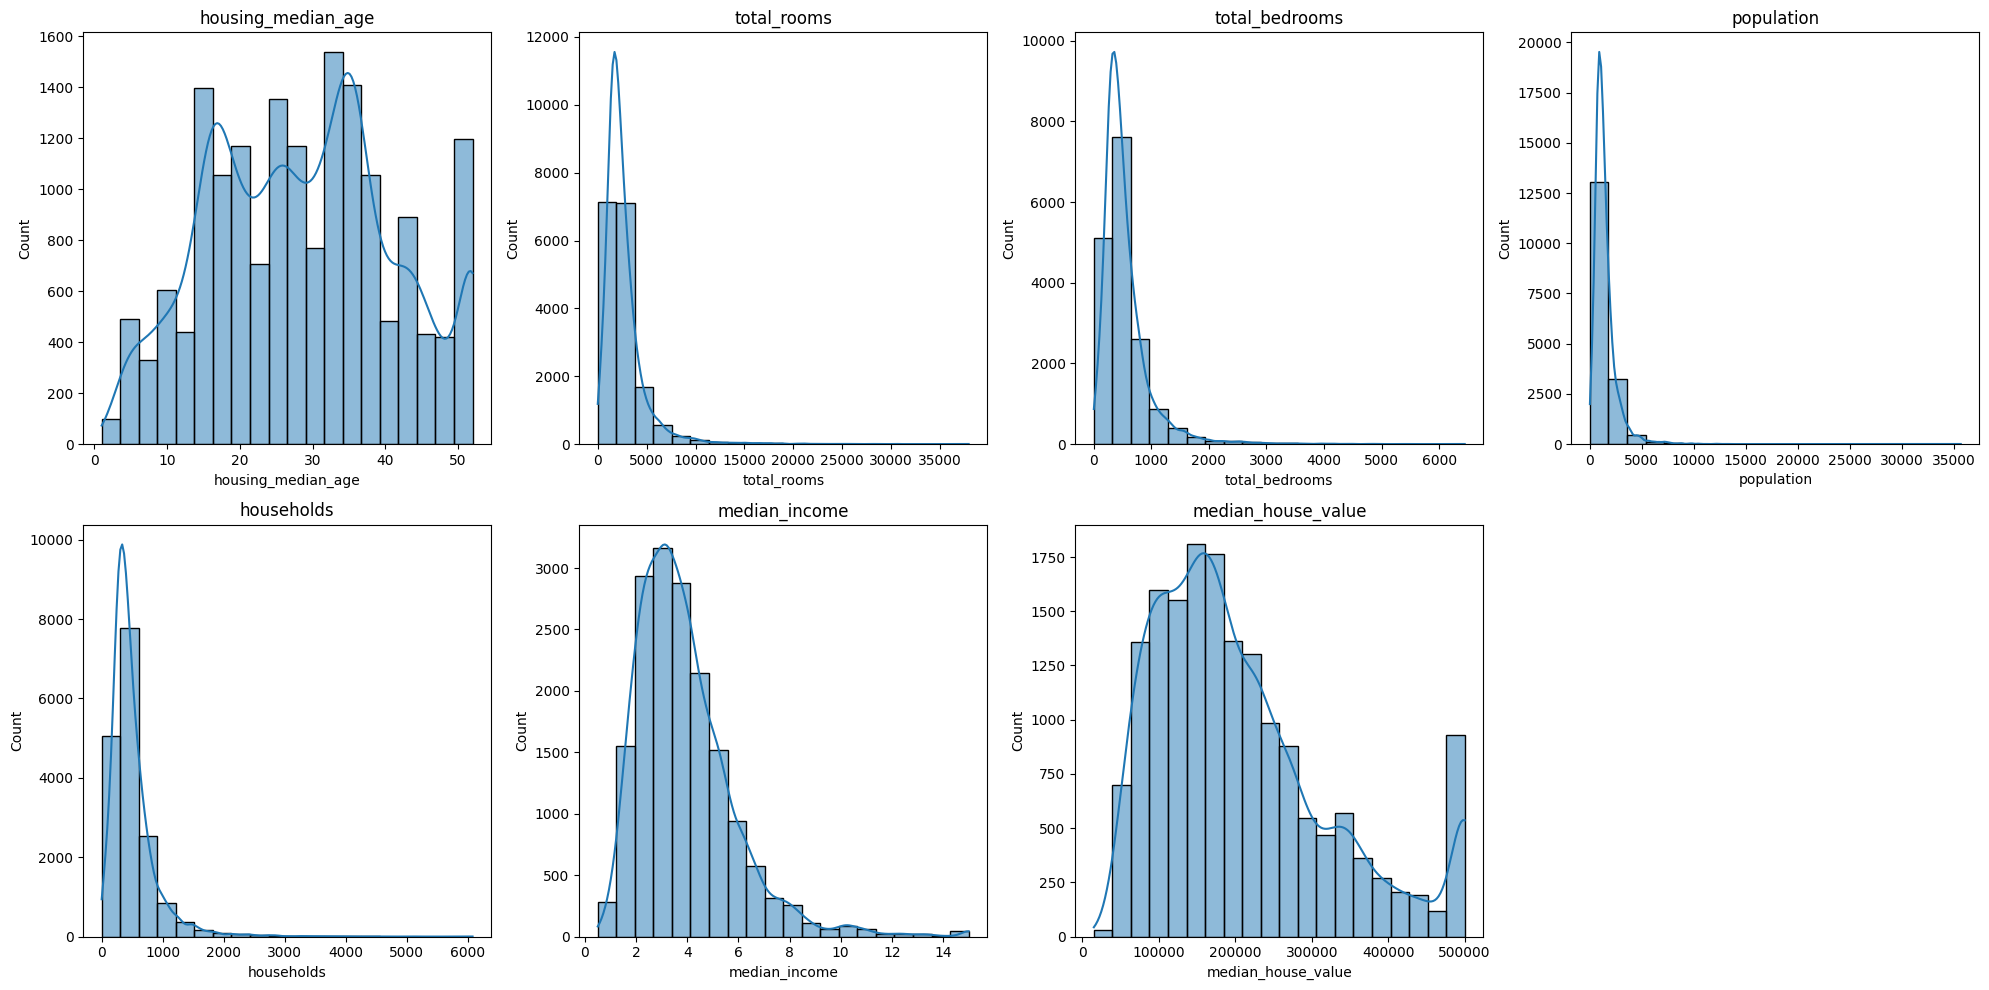

In [ ]:
s

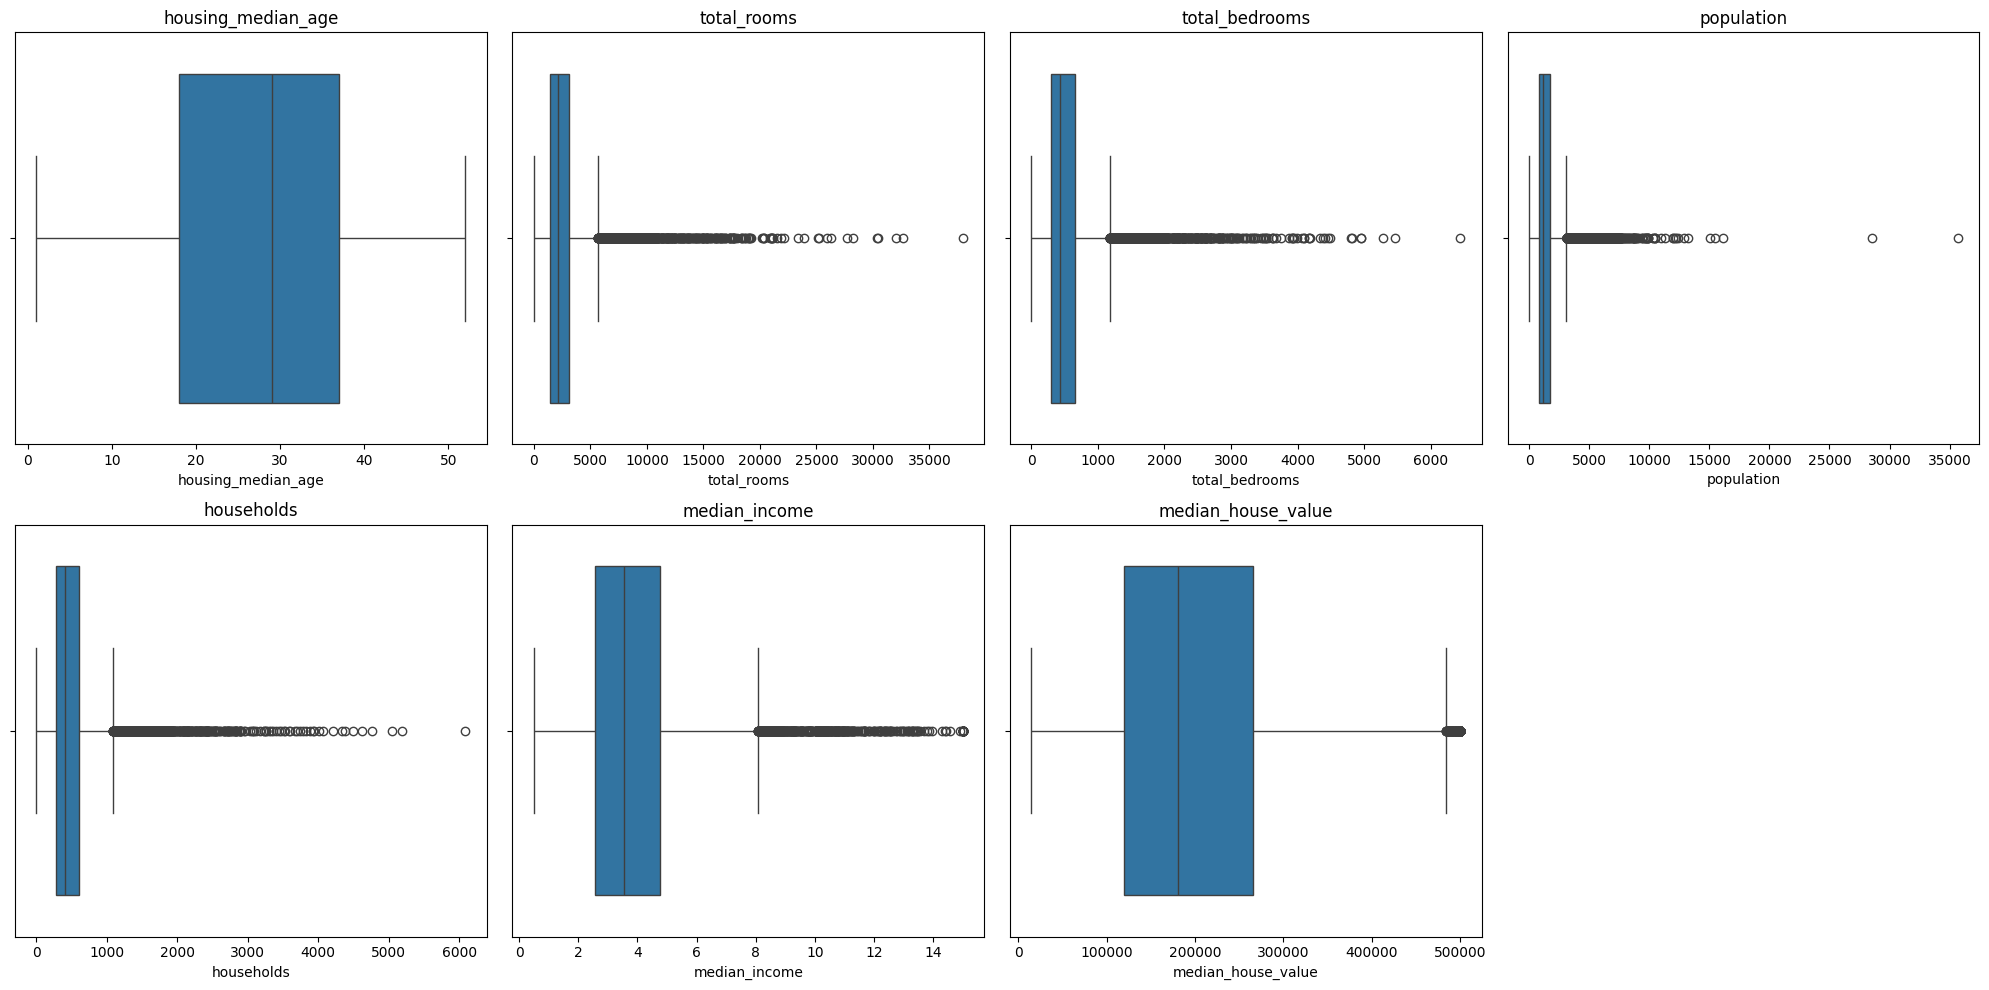

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
axes = axes.flatten()  # transforma em lista para facilitar o acesso

for i, feature in enumerate(numerical_features):
    sns.boxplot(x=df[feature], ax=axes[i])
    axes[i].set_title(feature)

# Deletar gráfico faltante
if len(numerical_features) < len(axes):
    for j in range(len(numerical_features), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
# Trantando a coluna media_income
df['median_income'] = df['median_income'] * 1000

<Axes: xlabel='median_income', ylabel='Count'>

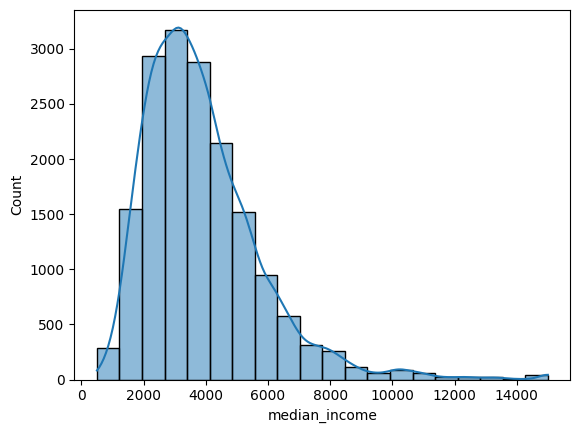

In [ ]:
sns.histplot(x=df['median_income'], kde=True, bins=20)

**Principais insights análisando as variáveis de maneira univariada:**
- A coluna de mediana na idade regiões (**housing_median_age**) com as casas está bem distribuída com uma mediana de 29 anos por região.

- A coluna do total de cômodos (**total_rooms**) tem muitos outliers e está desbalanceanda com o um maior número de regiões com um total de 10.000 ou menos cômodos.

- A coluna de total de quartos (**total_bedrooms**) está com um comportamento semelhante a coluna de total de cômodos o que pode indicar uma correlação. Quanto menor a quantidade de cômodos menor a quantiadede de quartos e vice-versa.

- A coluna de total de população de cada área (**population**) está bem concentrada em áreas de população baixa e uma boa quantidade de outliers (áreas com uma população muito acima da média ou mediana).

- A coluna do número de famílias (**households**) está com o comportamento semelhante ao de população.

- A coluna média de renda (**media_income**) mostra que a maioria dos casos tem a mediana da renda mais baixa com poucos casos de renda muito alta. A moda ocorro por volta de 3.000 e 3.500, indicando a faixa mais comum da mediana.

- A coluna com mediana do preço da casa (**median_house_value**) ja tem um balanceamento um pouco maior mas com a maioria dos casos por volta de 150.000 e 200.000 mil doláres


<Axes: >

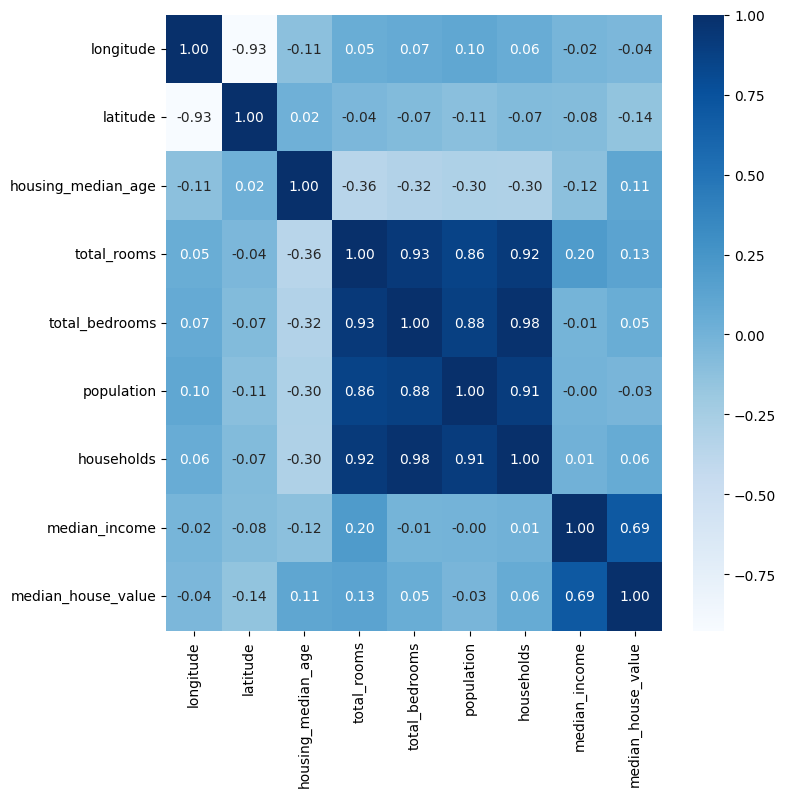

In [ ]:
correlacoes = df.corr()
plt.figure(figsize=(8, 8))
sns.heatmap(correlacoes,
            annot=True,
            fmt='.2f',
            cmap='Blues')

In [ ]:
df['median_income'].quantile([0.25, 0.5, 0.75])

,median_income
0.25,2566.375
0.50,3544.600
0.75,4767.000


In [ ]:
df['median_income_faixa'] = pd.cut(df['median_income'], bins=[0, 2566, 3544, 4767, np.inf],
                              labels=['<=2.566', '2.566 - 3544', '3544 - 4767', '>=4767'])




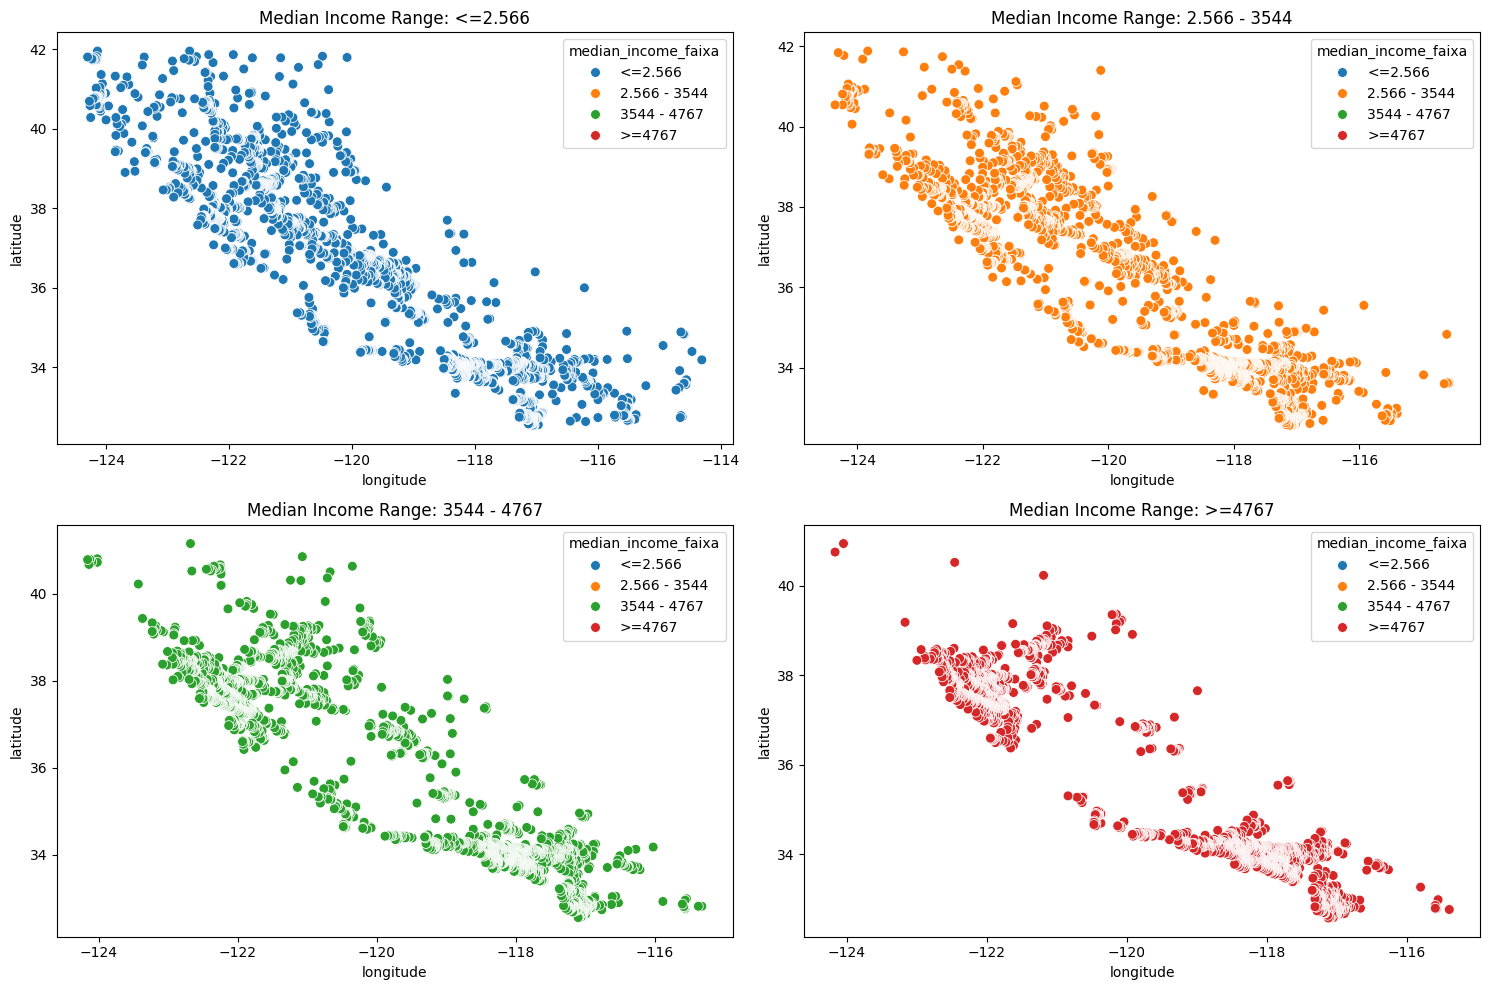

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

income_ranges = df['median_income_faixa'].unique()

for i, income_range in enumerate(income_ranges):
    row = i // 2
    col = i % 2

    subset = df[df['median_income_faixa'] == income_range]
    sns.scatterplot(x=subset['longitude'], y=subset['latitude'], hue=subset['median_income_faixa'], s=50, alpha=1, ax=axes[row, col])
    axes[row, col].set_title(f"Median Income Range: {income_range}")

plt.tight_layout()
plt.show()


<Axes: xlabel='longitude', ylabel='latitude'>

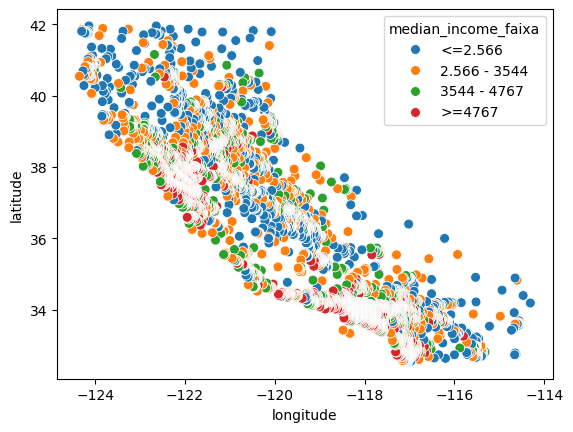

In [ ]:
sns.scatterplot(x=df['longitude'], y=df['latitude'], hue=df['median_income_faixa'], s=50, alpha=1)

# **Aula 6 - Análise de Outliers**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('https://jpbarddal.github.io/'
                 'assets/data/datascience/enron.csv')

In [3]:
df.head()

,bonus,deferral_payments,deferred_income,director_fees,email_address,exercised_stock_options,expenses,from_messages,from_poi_to_this_person,from_this_person_to_poi,...,other,poi,restricted_stock,restricted_stock_deferred,salary,shared_receipt_with_poi,to_messages,total_payments,total_stock_value,name
0,4175000.0,2869717.0,-3081055.0,NaN,phillip.allen@enron.com,1729541.0,13868.0,2195.0,47.0,65.0,...,152.0,False,126027.0,-126027.0,201955.0,1407.0,2902.0,4484442.0,1729541.0,ALLEN PHILLIP K
1,NaN,178980.0,NaN,NaN,NaN,257817.0,3486.0,NaN,NaN,NaN,...,NaN,False,NaN,NaN,NaN,NaN,NaN,182466.0,257817.0,BADUM JAMES P
2,NaN,NaN,-5104.0,NaN,james.bannantine@enron.com,4046157.0,56301.0,29.0,39.0,0.0,...,864523.0,False,1757552.0,-560222.0,477.0,465.0,566.0,916197.0,5243487.0,BANNANTINE JAMES M
3,1200000.0,1295738.0,-1386055.0,NaN,NaN,6680544.0,11200.0,NaN,NaN,NaN,...,2660303.0,False,3942714.0,NaN,267102.0,NaN,NaN,5634343.0,10623258.0,BAXTER JOHN C
4,400000.0,260455.0,-201641.0,NaN,frank.bay@enron.com,NaN,129142.0,NaN,NaN,NaN,...,69.0,False,145796.0,-82782.0,239671.0,NaN,NaN,827696.0,63014.0,BAY FRANKLIN R


In [4]:
# lista de outliers
outliers = []

# dicionario (linha -> colunas)
dict_ix_colunas_outlier = {}

# laco de repeticao que avança nas colunas NUMERICAS
for col in df.select_dtypes(include='number').columns:
  #print(f'Col: {col}')

  # Calculando quartis
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)

  # Calculando IQR
  iqr = q3 - q1

  # print(f'Q1: {q1} \t Q3: {q3} \t IQR: {iqr}')

  # Whiskers
  whisker_sup = q3 + 1.5 * iqr
  whisker_inf = q1 - 1.5 * iqr

  # condicao para ser outlier (x < whisker_inf | x > whisker_sup)
  outliers_col = list(df[(df[col] < whisker_inf) | (df[col] > whisker_sup)].index)

  # print(outliers_col)
  # Guarda em outliers todos os valores em outlier_col
  outliers.extend(outliers_col)
  # identico a:
  #for ix in outliers_col:
  #  outliers.append(ix)

  # armazenando colunas para cada indice
  for ix in outliers_col:
    if ix not in dict_ix_colunas_outlier:
      dict_ix_colunas_outlier[ix] = []
    dict_ix_colunas_outlier[ix].append(col)

from collections import Counter
outliers_freq = Counter(outliers)
for ix, contagem in outliers_freq.most_common(10):
  print(f'Indice: {ix} \t apareceu como outlier {contagem} vezes')

Indice: 130 	 apareceu como outlier 13 vezes
Indice: 47 	 apareceu como outlier 9 vezes
Indice: 7 	 apareceu como outlier 8 vezes
Indice: 79 	 apareceu como outlier 8 vezes
Indice: 78 	 apareceu como outlier 7 vezes
Indice: 139 	 apareceu como outlier 7 vezes
Indice: 122 	 apareceu como outlier 6 vezes
Indice: 0 	 apareceu como outlier 5 vezes
Indice: 75 	 apareceu como outlier 5 vezes
Indice: 3 	 apareceu como outlier 5 vezes


### **Pré-processamento**

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer

In [6]:
df = pd.read_csv('https://jpbarddal.github.io/assets/data/datascience/titanic.csv')

In [7]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [8]:
df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)

In [9]:
X, y = df.drop('Survived', axis=1), df['Survived']

<Axes: xlabel='Age', ylabel='Count'>

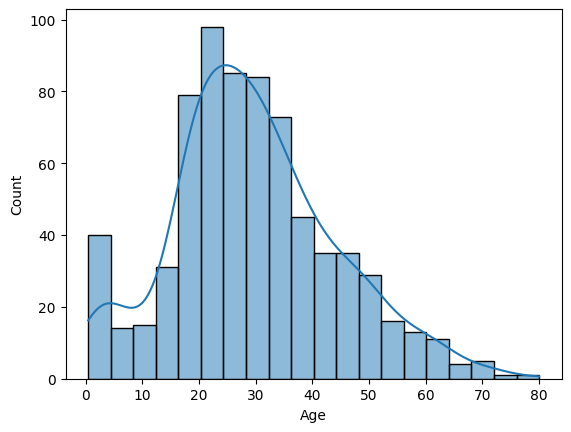

In [11]:
sns.histplot(x=df['Age'], kde=True)

<Axes: xlabel='Fare', ylabel='Count'>

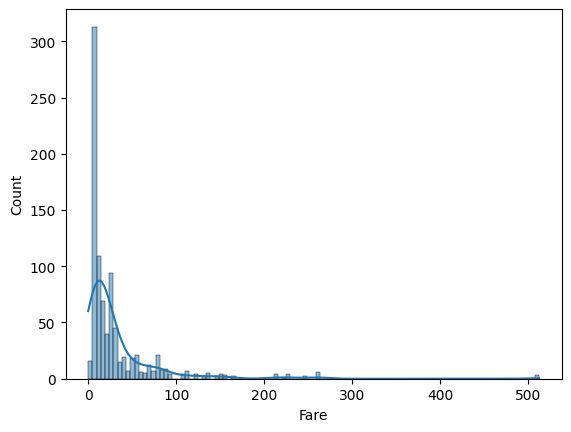

In [12]:
sns.histplot(x=df['Fare'], kde=True)

In [13]:
100 * X.isna().sum() / len(X)

,0
Pclass,0.000000
Sex,0.000000
Age,19.865320
SibSp,0.000000
Parch,0.000000
Fare,0.000000
Embarked,0.224467


In [14]:
df[df['Embarked'].isna()]

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
61,1,1,female,38.0,0,0,80.0,NaN
829,1,1,female,62.0,0,0,80.0,NaN


In [15]:
len(df)

891

In [16]:
df['Survived'].value_counts() / len(df)

,count
Survived,
0,0.616162
1,0.383838


In [ ]:
# Imputação das númericas por mediana e categóricas por moda
# OneHotEncode: Sex, Embarked
# Escala
# Assimetria: normalização

In [40]:
# Colunas para a imputação
cols_imp_num = [ 'Age']
cols_imp_cat = ['Embarked']
colunas_onehot = ['imp_cat__Embarked', 'remainder__Sex']

In [41]:
pipeline = Pipeline(
    steps=[
        # Imputação de valores faltantes
        ('imp', ColumnTransformer(
            transformers = [
                # nome, estrategia de imputação e colunas
                # set_output para transformar em uma tabela do pandas novamente depois do .fit_transform
                ('imp_num', SimpleImputer(strategy='median').set_output(transform='pandas'), cols_imp_num),
                ('imp_cat', SimpleImputer(strategy='most_frequent').set_output(transform='pandas'), cols_imp_cat)
            ]
        , remainder = 'passthrough').set_output(transform='pandas')),
        # Fazendo o OneHotEncoding para as colunas categoricas
        ('cat', ColumnTransformer(
            transformers=[
                ('ohe', OneHotEncoder(drop='first', sparse_output=False).set_output(transform='pandas'), colunas_onehot)
            ]
        , remainder='passthrough').set_output(transform='pandas')),
        ('norm', PowerTransformer(method='yeo-johnson').set_output(transform='pandas')),
        ('scale', MinMaxScaler().set_output(transform='pandas'))
    ])

In [42]:
pipeline

Pipeline(steps=[('imp',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('imp_num',
                                                  SimpleImputer(strategy='median'),
                                                  ['Age']),
                                                 ('imp_cat',
                                                  SimpleImputer(strategy='most_frequent'),
                                                  ['Embarked'])])),
                ('cat',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['imp_cat__Embarked',
                                                   'remainder__Sex'])])),
                ('norm', PowerTransformer()), ('scale', MinMaxScaler())])

In [43]:
# trasform pega a tabela re processa a tabela e retorna uma tabela no final
pipeline.fit_transform(X)

,ohe__imp_cat__Embarked_Q,ohe__imp_cat__Embarked_S,ohe__remainder__Sex_male,remainder__imp_num__Age,remainder__remainder__Pclass,remainder__remainder__SibSp,remainder__remainder__Parch,remainder__remainder__Fare
0,0.0,1.0,1.0,0.343160,1.000000,0.8348,0.000000,0.408170
1,0.0,0.0,0.0,0.542804,0.000000,0.8348,0.000000,0.748736
2,0.0,1.0,0.0,0.395247,1.000000,0.0000,0.000000,0.421814
3,0.0,1.0,0.0,0.506943,0.000000,0.8348,0.000000,0.707339
4,0.0,1.0,1.0,0.506943,1.000000,0.0000,0.000000,0.424216
...,...,...,...,...,...,...,...,...
886,0.0,1.0,1.0,0.408006,0.373003,0.0000,0.000000,0.497930
887,0.0,1.0,0.0,0.302837,0.000000,0.0000,0.000000,0.624414
888,0.0,1.0,0.0,0.420670,1.000000,0.8348,0.988843,0.587672
889,0.0,0.0,1.0,0.395247,0.000000,0.0000,0.000000,0.624414
